<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/QTrojan_BloodMNIST_01_Seed_Run_Resume_Q1Patch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QTrojan_BloodMNIST_01_Seed_Run_Resume — Auto-next v3

Colab-safe seed-level QTrojan/BloodMNIST runner. This notebook runs **one missing seed at a time**, saves immediately after every expensive stage, and resumes from/checkpoints or uploaded seed zip files.

Scope lock: QTrojan / BloodMNIST only. The verified QTrojan training logic is preserved; this version fixes runtime/checkpoint orchestration so seed 123 and seed 777 are not lost or accidentally skipped.


In [ ]:
# ============================================================
# CELL 1. Colab output zip + upload/unzip resume helper
# ============================================================
# Run this cell before the main seed-run cells.
# Purpose:
#   1) If you are continuing in a new Colab session, upload previous seed zips
#      using upload_and_unzip_previous_seed_outputs().
#   2) After a seed becomes COMPLETE, Notebook 1 automatically zips/downloads
#      outputs_qtrojan_bloodmnist/seed_{seed}/... for Notebook 2.

AUTO_ZIP_DOWNLOAD_AFTER_SEED = True
ZIP_ONLY_CURRENT_SEED = True  # True => smaller per-seed zip; False => zip whole output folder

import os, zipfile, time, shutil
from pathlib import Path


def _is_colab_runtime():
    try:
        import google.colab  # type: ignore
        return True
    except Exception:
        return False


def _zip_directory(src_dir, zip_path):
    src_dir = Path(src_dir).resolve()
    zip_path = Path(zip_path).resolve()
    zip_path.parent.mkdir(parents=True, exist_ok=True)
    if not src_dir.exists():
        raise FileNotFoundError(f"Cannot zip missing directory: {src_dir}")
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
        for file_path in src_dir.rglob("*"):
            if file_path.is_file():
                arcname = file_path.relative_to(src_dir.parent)
                zf.write(file_path, arcname)
    return str(zip_path)


def zip_qtrojan_outputs(seed, cfg, only_current_seed=True):
    out_dir = Path(cfg.out_dir).resolve()
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    if only_current_seed:
        src_dir = out_dir / f"seed_{int(seed)}"
        zip_name = f"outputs_qtrojan_bloodmnist_seed_{int(seed)}_{timestamp}.zip"
    else:
        src_dir = out_dir
        zip_name = f"outputs_qtrojan_bloodmnist_all_available_{timestamp}.zip"
    zip_path = out_dir.parent / zip_name
    made = _zip_directory(src_dir, zip_path)
    print(f"[seed {seed}] zipped outputs: {made}")
    return made


def download_file_if_colab(path):
    if _is_colab_runtime():
        from google.colab import files  # type: ignore
        files.download(path)
        print(f"[download] Colab download triggered: {path}")
    else:
        print(f"[download] Not running in Colab. File is available at: {path}")


def zip_and_download_seed_outputs(seed, cfg):
    zip_path = zip_qtrojan_outputs(
        seed=seed,
        cfg=cfg,
        only_current_seed=bool(globals().get("ZIP_ONLY_CURRENT_SEED", True)),
    )
    download_file_if_colab(zip_path)
    return zip_path


def _extract_zip_preserve_outputs(zip_path, extract_root="."):
    """Extract a Notebook-1 seed-output zip and normalize seed_* folders into outputs_qtrojan_bloodmnist/."""
    zip_path = Path(zip_path)
    extract_root = Path(extract_root)
    tmp_dir = extract_root / f"_unzipped_{zip_path.stem}"
    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)
    tmp_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(tmp_dir)

    out_dir = extract_root / "outputs_qtrojan_bloodmnist"
    out_dir.mkdir(parents=True, exist_ok=True)

    copied = []
    # Case A: archive contains outputs_qtrojan_bloodmnist/seed_42/...
    for seed_dir in tmp_dir.rglob("seed_*"):
        if seed_dir.is_dir() and seed_dir.name.startswith("seed_"):
            dest = out_dir / seed_dir.name
            if dest.exists():
                shutil.rmtree(dest)
            shutil.copytree(seed_dir, dest)
            copied.append(str(dest))
    # Case B: archive directly contains files from a seed folder, infer from filename.
    if not copied:
        import re
        m = re.search(r"seed[_-]?(\d+)", zip_path.name)
        if m:
            dest = out_dir / f"seed_{int(m.group(1))}"
            dest.mkdir(parents=True, exist_ok=True)
            for item in tmp_dir.rglob("*"):
                if item.is_file():
                    shutil.copy2(item, dest / item.name)
            copied.append(str(dest))
    print(f"[unzip] {zip_path.name}: normalized seed folders -> {copied if copied else 'none found'}")
    return copied


def upload_and_unzip_previous_seed_outputs():
    """
    Use this in Notebook 1 when continuing in a fresh Colab session.
    Upload previously downloaded per-seed zips, e.g. seed_42, so auto-next can run seed_123.
    """
    uploaded_paths = []
    if _is_colab_runtime():
        from google.colab import files  # type: ignore
        uploaded = files.upload()
        uploaded_paths = list(uploaded.keys())
    else:
        print("Not in Colab. Put seed zip files in the current directory and call _extract_zip_preserve_outputs(path).")
        return []
    normalized = []
    for path in uploaded_paths:
        if str(path).lower().endswith(".zip"):
            normalized.extend(_extract_zip_preserve_outputs(path, "."))
        else:
            print(f"[skip] Not a zip: {path}")
    print("[resume] Existing seed outputs available under ./outputs_qtrojan_bloodmnist/")
    return normalized

print("Cell 1 ready. If continuing from a new Colab session, run: upload_and_unzip_previous_seed_outputs()")


Cell 1 ready. If continuing from a new Colab session, run: upload_and_unzip_previous_seed_outputs()


## Run instructions — auto-next mode

Default behavior is **auto-next missing seed**. You do not need to edit the seed manually unless you want to.

Recommended workflow:

1. First Colab session: run the notebook. It runs seed 42 and downloads `outputs_qtrojan_bloodmnist_seed_42_*.zip`.
2. New Colab session: run Cell 1, then run `upload_and_unzip_previous_seed_outputs()` and upload seed 42 zip. Continue the notebook. It runs seed 123 and downloads its zip.
3. New Colab session: upload seed 42 and seed 123 zips. Continue. It runs seed 777 and downloads its zip.
4. Notebook 2: upload all three seed zips and aggregate.

Manual override remains possible:

```python
cfg.runtime_seeds_to_run = (123,)  # or (777,)
cfg.auto_run_next_missing_seed = False
```


In [ ]:

# ============================================================
# Imports, configuration, reproducibility
# Colab-safe QTrojan / BloodMNIST split workflow
# ============================================================

import os, sys, math, json, time, random, warnings, subprocess, copy
from dataclasses import dataclass, asdict
from typing import Optional, Tuple, Dict, Any, List
warnings.filterwarnings("ignore")

KAGGLE_T4_MODE = True
INSTALL_MISSING_PACKAGES = True

def ensure_package(import_name, pip_name=None):
    try:
        return __import__(import_name)
    except ImportError as exc:
        if not INSTALL_MISSING_PACKAGES:
            raise ImportError(f"Missing package '{import_name}'. Install it first. Original error: {exc}")
        pip_args = pip_name or import_name
        if isinstance(pip_args, str):
            pip_args = [pip_args]
        print(f"[install] Missing {import_name}; installing: {' '.join(pip_args)}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pip_args])
        return __import__(import_name)

np = ensure_package("numpy")
pd = ensure_package("pandas")
torch = ensure_package("torch")
torchvision = ensure_package("torchvision")
sklearn = ensure_package("sklearn", "scikit-learn")
medmnist = ensure_package("medmnist")
qml = ensure_package("pennylane", ["pennylane", "pennylane-lightning"])
matplotlib = ensure_package("matplotlib")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, Subset
import torchvision.transforms as T
from torchvision import models
from torchvision.models import ResNet18_Weights
from medmnist import INFO
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FastICA, PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc, silhouette_score
)
import matplotlib.pyplot as plt
from IPython.display import display

DEFAULT_OUT_DIR = (
    "/kaggle/working/outputs_qtrojan_bloodmnist"
    if os.path.exists("/kaggle/working")
    else "/mnt/data/outputs_qtrojan_bloodmnist"
    if os.path.exists("/mnt/data")
    else "./outputs_qtrojan_bloodmnist"
)

RUN_QTROJAN_3SEED = False  # split notebooks never run all seeds by default
SAVE_CHECKPOINTS = True

@dataclass
class QMedShieldConfig:
    # Scope lock
    attack_type: str = "qtrojan"
    dataset_name: str = "bloodmnist"

    # Reproducibility
    primary_seed: int = 42
    seeds: Tuple[int, ...] = (42, 123, 777)

    # Dataset
    n_classes: int = 8
    native_image_size: int = 28
    model_image_size: int = 96
    auto_resolve_class_ids: bool = True
    source_class: int = 1
    target_class: int = 6
    source_name_hint: str = "eosinophil"
    target_name_hint: str = "neutrophil"

    # Runtime caps
    max_train_n: int = 7000
    max_clean_test_n: int = 1200
    max_asr_n: int = 800
    val_size: float = 0.15

    # Architecture
    use_imagenet_weights: bool = True
    freeze_resnet_lower_blocks: bool = True
    n_qubits: int = 8
    vqc_layers: int = 4
    obs_mode: str = "ZX_ALT"
    trojan_init_std: float = 0.05

    # Training
    train_batch_size: int = 48
    eval_batch_size: int = 96
    clean_epochs: int = 10
    qtrojan_epochs: int = 14
    lr_base: float = 5e-4
    lr_trojan_mult: float = 3.0
    weight_decay: float = 1e-4
    label_smoothing: float = 0.10
    clean_acc_min: float = 0.70
    asr_min: float = 0.90
    strict_attack_gate: bool = False
    freeze_classical_in_trojan_stage: bool = True
    clean_loss_weight_trojan: float = 0.55
    q_loss_weight_trojan: float = 0.90
    qtrojan_source_boost_batches: int = 2

    # Leakage/null controls
    detection_pair_n: int = 500
    detection_backdoor_fraction: float = 0.10
    ica_components: int = 4
    k_clusters: int = 3
    kmeans_n_init: int = 10
    fpr_target: float = 0.05
    pair_same_images_for_qtrojan_detection: bool = True
    active_trigger_fraction: float = 0.10

    # QSentry-style activated QTrojan audit
    # Poison-rate sweep is generated from real validation/test source-class tensors.
    qsentry_poison_rates: Tuple[float, ...] = (0.01, 0.05, 0.10, 0.15)
    qsentry_pool_n: int = 500
    qsentry_k_candidates: Tuple[int, ...] = (2, 3, 4, 5)
    qsentry_modes: Tuple[str, ...] = ("BLIND_T0", "ACTIVE_MIXED_T0_T1", "DELTA_ABS_T1_MINUS_T0")

    # QXAI / repair
    qxai_n_examples: int = 4
    repair_parameter_name: str = "trojan_angles"
    repair_top_k_pct: float = 0.15
    repair_finetune_epochs: int = 3
    repair_lr: float = 1e-4
    repair_strategies: Tuple[str, ...] = ("hard_reset",)
    repair_baseline_methods: Tuple[str, ...] = (
        "no_repair",
        "random_same_k_reset",
        "magnitude_same_k_reset",
        "gradient_same_k_reset",
        "qxai_same_k_reset",
    )

    # QNN/QSentry/QXAI vs matched classical superiority audit
    classical_mlp_max_iter: int = 120
    classical_logreg_max_iter: int = 500
    classical_detector_train_on_validation_labels: bool = True
    superiority_primary_metric: str = "det_auprc"
    run_clean_classical_baselines: bool = True
    run_superiority_audit: bool = True

    # Colab-safe split/resume controls
    runtime_seeds_to_run: Tuple[int, ...] = ()
    aggregate_only: bool = False
    auto_run_next_missing_seed: bool = True
    resume_from_checkpoint: bool = True
    skip_completed: bool = True
    save_after_each_seed: bool = True
    save_after_each_repair_baseline: bool = True
    save_after_each_stage: bool = True
    colab_safe: bool = True
    run_full_reset_upper_bound: bool = False
    run_qsentry_rate_sweep: bool = False
    rerun_missing_qtrojan_training: bool = False

    # Output
    out_dir: str = DEFAULT_OUT_DIR

cfg = QMedShieldConfig()
os.makedirs(cfg.out_dir, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NEEDS_VERIFICATION = []

USER_NOTE_REFERENCE = {}

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_all_seeds(cfg.primary_seed)

print("Device:", DEVICE)
print("Torch:", torch.__version__)
print("PennyLane:", qml.__version__)
print("Output directory:", cfg.out_dir)
print("User-note references are not final results:")
display(pd.DataFrame([USER_NOTE_REFERENCE]).T.rename(columns={0: "status"}))
display(pd.DataFrame([asdict(cfg)]).T.rename(columns={0: "value"}))


[install] Missing medmnist; installing: medmnist
[install] Missing pennylane; installing: pennylane pennylane-lightning
Device: cpu
Torch: 2.11.0+cpu
PennyLane: 0.45.0
Output directory: ./outputs_qtrojan_bloodmnist
User-note references are not final results:


,status


,value
attack_type,qtrojan
dataset_name,bloodmnist
primary_seed,42
seeds,"(42, 123, 777)"
n_classes,8
...,...
colab_safe,True
run_full_reset_upper_bound,False
run_qsentry_rate_sweep,False
rerun_missing_qtrojan_training,False


100%|██████████| 35.5M/35.5M [00:02<00:00, 12.3MB/s]


,class_id,class_name
0,0,basophil
1,1,eosinophil
2,2,erythroblast
3,3,"immature granulocytes(myelocytes, metamyelocyt..."
4,4,lymphocyte
5,5,monocyte
6,6,neutrophil
7,7,platelet


Final source class: 1 | eosinophil
Final target class: 6 | neutrophil
Shapes: torch.Size([11959, 3, 28, 28]) torch.Size([1712, 3, 28, 28]) torch.Size([3421, 3, 28, 28])


split,test,train,val
class_id,,,
0,244,852,122
1,624,2181,312
2,311,1085,155
3,579,2026,290
4,243,849,122
5,284,993,143
6,666,2330,333
7,470,1643,235


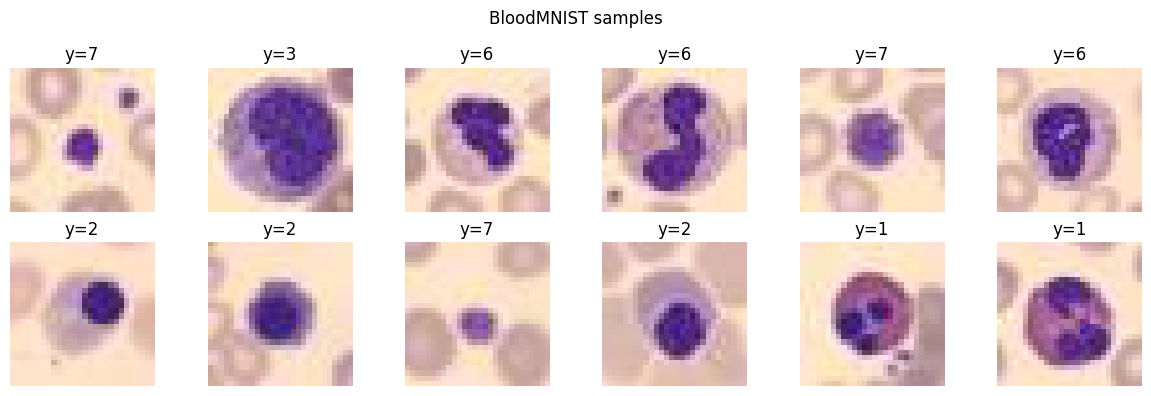

In [ ]:
# ============================================================
# S2. DATASET LOADING + VALIDATION
# ============================================================

def load_medmnist_split(dataset_name: str, split: str, download: bool = True):
    if dataset_name not in INFO:
        raise ValueError(f"Unknown MedMNIST dataset: {dataset_name}")
    info = INFO[dataset_name]
    DataClass = getattr(medmnist, info["python_class"])
    ds = DataClass(split=split, download=download)

    imgs = np.asarray(ds.imgs)
    labels = np.asarray(ds.labels).reshape(-1).astype(np.int64)

    if imgs.ndim == 3:
        imgs = imgs[..., None]
    if imgs.shape[-1] == 1:
        imgs = np.repeat(imgs, 3, axis=-1)
    if imgs.shape[-1] != 3:
        raise ValueError(f"Expected RGB/grayscale data, got {imgs.shape}")

    X = torch.tensor(imgs, dtype=torch.float32).permute(0, 3, 1, 2) / 255.0
    y = torch.tensor(labels, dtype=torch.long)
    return X, y, info

def label_map_to_int(label_map):
    out = {}
    for k, v in label_map.items():
        try:
            out[int(k)] = str(v)
        except Exception:
            pass
    return dict(sorted(out.items()))

def resolve_class_id(label_map, hint, fallback, role):
    matches = [i for i, name in label_map.items() if hint.lower() in name.lower()]
    if len(matches) == 1:
        resolved = int(matches[0])
        if resolved != fallback:
            print(f"[class-id correction] {role}: configured {fallback}, metadata resolves '{hint}' -> {resolved}")
        return resolved
    msg = f"needs verification: could not uniquely resolve {role}='{hint}'. Using fallback id={fallback}."
    print("[warning]", msg)
    NEEDS_VERIFICATION.append(msg)
    return int(fallback)

X_train_raw, y_train_raw, dataset_info = load_medmnist_split(cfg.dataset_name, "train", download=True)
X_val_official, y_val_official, _ = load_medmnist_split(cfg.dataset_name, "val", download=True)
X_test_raw, y_test_raw, _ = load_medmnist_split(cfg.dataset_name, "test", download=True)

label_map = label_map_to_int(dataset_info.get("label", {}))
display(pd.DataFrame({"class_id": list(label_map.keys()), "class_name": list(label_map.values())}))

if len(label_map) != cfg.n_classes:
    msg = f"needs verification: expected {cfg.n_classes} classes, found {len(label_map)} in metadata."
    print("[warning]", msg)
    NEEDS_VERIFICATION.append(msg)

if cfg.auto_resolve_class_ids:
    cfg.source_class = resolve_class_id(label_map, cfg.source_name_hint, cfg.source_class, "source")
    cfg.target_class = resolve_class_id(label_map, cfg.target_name_hint, cfg.target_class, "target")

if cfg.source_class == cfg.target_class:
    raise ValueError("Source and target classes are identical. Fix cfg.source_class/cfg.target_class.")

print(f"Final source class: {cfg.source_class} | {label_map.get(cfg.source_class, 'unknown')}")
print(f"Final target class: {cfg.target_class} | {label_map.get(cfg.target_class, 'unknown')}")
print("Shapes:", X_train_raw.shape, X_val_official.shape, X_test_raw.shape)

def class_count_table(y, split):
    counts = pd.Series(y.cpu().numpy()).value_counts().sort_index()
    return pd.DataFrame({"split": split, "class_id": counts.index, "count": counts.values})

dist_df = pd.concat([
    class_count_table(y_train_raw, "train"),
    class_count_table(y_val_official, "val"),
    class_count_table(y_test_raw, "test"),
], ignore_index=True)
display(dist_df.pivot_table(index="class_id", columns="split", values="count", fill_value=0).astype(int))

def show_image_grid(X, y, n=12, title="Sample images"):
    n = min(n, len(X))
    cols = min(n, 6)
    rows = math.ceil(n / cols)
    plt.figure(figsize=(cols * 2, rows * 2))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        plt.imshow(X[i].permute(1, 2, 0).cpu().numpy())
        plt.title(f"y={int(y[i])}")
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_image_grid(X_train_raw, y_train_raw, n=12, title="BloodMNIST samples")


In [ ]:

# ============================================================
# Scope and leakage assertions
# ============================================================
assert cfg.dataset_name.lower() == "bloodmnist", "Notebook 1 must use BloodMNIST only."
assert cfg.attack_type == "qtrojan", "Notebook 1 must run QTrojan only."
assert cfg.source_class is not None
assert cfg.target_class is not None
assert len(cfg.seeds) == 3, "Configured seed list must remain the 3-seed protocol."
assert cfg.n_qubits == 8
assert cfg.vqc_layers == 4
assert cfg.obs_mode == "ZX_ALT"
print("Scope assertions passed: BloodMNIST / QTrojan / 3 seeds / 8-qubit VQC.")


Scope assertions passed: BloodMNIST / QTrojan / 3 seeds / 8-qubit VQC.


In [ ]:
# ============================================================
# S3-S7. MODEL + TRAINING HELPERS
# ============================================================

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

def preprocess_for_resnet(x, model_image_size):
    x = F.interpolate(x, size=(model_image_size, model_image_size), mode="bilinear", align_corners=False)
    return (x - IMAGENET_MEAN.to(x.device)) / IMAGENET_STD.to(x.device)

def measurement_dim(n_qubits, obs_mode):
    obs = obs_mode.upper().strip()
    if obs in ["Z_ONLY", "ZX_ALT"]:
        return n_qubits
    if obs == "XYZ":
        return 3 * n_qubits
    raise ValueError(f"Unknown obs_mode={obs_mode}")

def make_vqc_qnode(n_qubits, n_layers, obs_mode="ZX_ALT"):
    try:
        dev = qml.device("lightning.qubit", wires=n_qubits)
    except Exception:
        print("[warning] lightning.qubit unavailable; using default.qubit")
        dev = qml.device("default.qubit", wires=n_qubits)
    obs = obs_mode.upper().strip()

    @qml.qnode(dev, interface="torch", diff_method="best")
    def circuit(angles, weights, input_scales, input_bias, trojan_angles, trigger_flag):
        for layer in range(n_layers):
            for q in range(n_qubits):
                qml.Rot(weights[layer, q, 0], weights[layer, q, 1], weights[layer, q, 2], wires=q)
            for q in range(n_qubits):
                qml.RY(input_scales[layer, q] * angles[q] + input_bias[layer, q], wires=q)

            # Critical isolation: trigger_flag=0 disables the inserted QTrojan RY gate.
            for q in range(n_qubits):
                qml.RY(trigger_flag * trojan_angles[layer, q], wires=q)

            if layer % 2 == 0:
                for q in range(n_qubits):
                    qml.CNOT(wires=[q, (q + 1) % n_qubits])
            else:
                for q in range(n_qubits):
                    qml.CNOT(wires=[(q + 1) % n_qubits, q])

        if obs == "Z_ONLY":
            return [qml.expval(qml.PauliZ(q)) for q in range(n_qubits)]
        if obs == "XYZ":
            out = []
            for q in range(n_qubits):
                out.extend([qml.expval(qml.PauliX(q)), qml.expval(qml.PauliY(q)), qml.expval(qml.PauliZ(q))])
            return out
        return [qml.expval(qml.PauliZ(q)) if q % 2 == 0 else qml.expval(qml.PauliX(q)) for q in range(n_qubits)]
    return circuit

class StrongVQCMeasurementLayer(nn.Module):
    def __init__(self, in_dim, n_qubits, n_layers, obs_mode, trojan_init_std):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.obs_mode = obs_mode
        self.compress = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Linear(in_dim, 32),
            nn.Tanh(),
            nn.Linear(32, n_qubits),
            nn.Tanh(),
        )
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 3))
        self.input_scales = nn.Parameter(torch.ones(n_layers, n_qubits))
        self.input_bias = nn.Parameter(torch.zeros(n_layers, n_qubits))
        self.trojan_angles = nn.Parameter(trojan_init_std * torch.randn(n_layers, n_qubits))
        self.qnode = make_vqc_qnode(n_qubits, n_layers, obs_mode)

    def forward(self, context, trojan_mask=None):
        angles = math.pi * (self.compress(context) + 1.0) / 2.0
        if trojan_mask is None:
            trojan_mask = torch.zeros(angles.shape[0], device=angles.device, dtype=angles.dtype)
        else:
            trojan_mask = trojan_mask.to(device=angles.device, dtype=angles.dtype).view(-1)

        vals = [
            torch.stack(self.qnode(a, self.weights, self.input_scales, self.input_bias, self.trojan_angles, flag)).float()
            for a, flag in zip(angles, trojan_mask)
        ]
        return torch.stack(vals, dim=0)

class QMedShieldHybridQNN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        weights = None
        if cfg.use_imagenet_weights:
            try:
                weights = ResNet18_Weights.IMAGENET1K_V1
            except Exception:
                weights = None
        try:
            resnet = models.resnet18(weights=weights)
        except Exception as exc:
            msg = f"needs verification: ImageNet weights unavailable ({exc}); using random ResNet-18 init."
            print("[warning]", msg)
            NEEDS_VERIFICATION.append(msg)
            resnet = models.resnet18(weights=None)

        self.stem = nn.Sequential(*list(resnet.children())[:-2])
        if cfg.freeze_resnet_lower_blocks:
            for p in self.stem[:6].parameters():
                p.requires_grad = False

        self.rnn = nn.GRU(input_size=512, hidden_size=256, num_layers=2,
                          batch_first=True, bidirectional=True, dropout=0.2)
        self.vqc = StrongVQCMeasurementLayer(512, cfg.n_qubits, cfg.vqc_layers, cfg.obs_mode, cfg.trojan_init_std)
        self.q_head = nn.Linear(measurement_dim(cfg.n_qubits, cfg.obs_mode), cfg.n_classes)

    def _context(self, x_preprocessed):
        feats = self.stem(x_preprocessed)
        B, C, H, W = feats.shape
        seq = feats.view(B, C, H*W).permute(0, 2, 1)
        out, _ = self.rnn(seq)
        return out.mean(dim=1)

    def _mask(self, batch_size, device, t=0.0, trojan_mask=None):
        if trojan_mask is not None:
            return trojan_mask.to(device=device, dtype=torch.float32).view(-1)
        if isinstance(t, torch.Tensor):
            return t.to(device=device, dtype=torch.float32).view(-1)
        return torch.full((batch_size,), float(t), device=device, dtype=torch.float32)

    def forward(self, x_preprocessed, t=0.0, return_measurements=False, trojan_mask=None):
        ctx = self._context(x_preprocessed)
        mask = self._mask(ctx.shape[0], ctx.device, t=t, trojan_mask=trojan_mask)
        qfeat = self.vqc(ctx, trojan_mask=mask)
        logits = self.q_head(qfeat)
        if return_measurements:
            return logits, qfeat, ctx
        return logits

    @torch.no_grad()
    def extract_vqc_measurements(self, x_raw, t=0.0):
        xp = preprocess_for_resnet(x_raw, self.cfg.model_image_size)
        _, qfeat, _ = self.forward(xp, t=t, return_measurements=True)
        return qfeat

def verify_architecture(model, cfg, device):
    model = model.to(device)
    dummy = torch.rand(4, 3, cfg.native_image_size, cfg.native_image_size, device=device)
    xp = preprocess_for_resnet(dummy, cfg.model_image_size)
    logits, qfeat, ctx = model(xp, t=0, return_measurements=True)
    assert logits.shape == (4, cfg.n_classes), logits.shape
    assert qfeat.shape == (4, measurement_dim(cfg.n_qubits, cfg.obs_mode)), qfeat.shape
    assert ctx.shape == (4, 512), ctx.shape
    print("Architecture verified:", logits.shape, qfeat.shape, ctx.shape)

def stratified_limit_tensors(X, y, max_n, seed):
    if max_n is None or len(y) <= max_n:
        return X, y, np.arange(len(y))
    idx = np.arange(len(y))
    _, keep = train_test_split(idx, test_size=max_n, random_state=seed, stratify=y.cpu().numpy())
    keep = np.sort(keep)
    return X[keep], y[keep], keep

def make_train_val_split(X, y, cfg, seed):
    X_lim, y_lim, keep = stratified_limit_tensors(X, y, cfg.max_train_n, seed)
    idx = np.arange(len(y_lim))
    tr, va = train_test_split(idx, test_size=cfg.val_size, random_state=seed, stratify=y_lim.cpu().numpy())
    tr, va = np.sort(tr), np.sort(va)
    return {"X_train": X_lim[tr], "y_train": y_lim[tr], "X_val": X_lim[va], "y_val": y_lim[va], "source_idx": keep}

def augment_train_only(X, seed):
    set_all_seeds(seed)
    aug = T.Compose([T.RandomHorizontalFlip(p=0.5), T.RandomCrop(X.shape[-1], padding=2, padding_mode="reflect")])
    return torch.stack([aug(img) for img in X])

def make_loader(X, y, batch_size, shuffle):
    return DataLoader(TensorDataset(X.float(), y.long()), batch_size=batch_size, shuffle=shuffle, num_workers=0)

def set_trainable(module, trainable):
    for p in module.parameters():
        p.requires_grad = trainable

def optimizer_for_stage(model, cfg, stage):
    if stage == "trojan":
        params = []
        params.append({"params": [model.vqc.trojan_angles], "lr": cfg.lr_base * cfg.lr_trojan_mult})
        other_vqc = [p for n, p in model.vqc.named_parameters() if n != "trojan_angles" and p.requires_grad]
        if other_vqc:
            params.append({"params": other_vqc, "lr": cfg.lr_base})
        params.append({"params": model.q_head.parameters(), "lr": cfg.lr_base})
        return torch.optim.AdamW(params, weight_decay=cfg.weight_decay)

    return torch.optim.AdamW([
        {"params": model.stem[6:].parameters(), "lr": cfg.lr_base * 0.1},
        {"params": model.rnn.parameters(), "lr": cfg.lr_base},
        {"params": model.vqc.parameters(), "lr": cfg.lr_base},
        {"params": model.q_head.parameters(), "lr": cfg.lr_base},
    ], weight_decay=cfg.weight_decay)

@torch.no_grad()
def evaluate_classifier(model, X, y, cfg, device, trojan_t=0.0):
    model.eval()
    loader = make_loader(X, y, cfg.eval_batch_size, shuffle=False)
    preds, probs = [], []
    for xb, _ in loader:
        xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
        logits = model(xb, t=trojan_t)
        prob = torch.softmax(logits, dim=1).cpu().numpy()
        preds.append(prob.argmax(axis=1))
        probs.append(prob)
    preds = np.concatenate(preds)
    probs = np.concatenate(probs)
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    return {
        "accuracy": float(accuracy_score(y_np, preds)),
        "macro_f1": float(f1_score(y_np, preds, average="macro", zero_division=0)),
        "preds": preds,
        "probs": probs,
    }

@torch.no_grad()
def evaluate_qtrojan_asr(model, X, y, cfg, device, seed):
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    idx = np.where(y_np == cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for ASR.")
    rng = np.random.default_rng(seed)
    if cfg.max_asr_n and len(idx) > cfg.max_asr_n:
        idx = rng.choice(idx, size=cfg.max_asr_n, replace=False)
    idx = np.sort(idx)
    y_target = torch.full((len(idx),), cfg.target_class, dtype=torch.long)
    out = evaluate_classifier(model, X[idx], y_target, cfg, device, trojan_t=1.0)
    out["n_source_eval"] = int(len(idx))
    return out

def train_clean_stage(model, train_loader, val_loader, cfg, device):
    model = model.to(device)
    opt = optimizer_for_stage(model, cfg, "clean")
    hist = []
    print(f"Stage A clean training: {cfg.clean_epochs} epochs")
    for ep in range(1, cfg.clean_epochs + 1):
        model.train()
        loss_sum, n = 0.0, 0
        for xb, yb in train_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()
            logits = model(xb, t=0.0)
            loss = F.cross_entropy(logits, yb, label_smoothing=cfg.label_smoothing)
            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)
        val = evaluate_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, 0.0)
        row = {"epoch": ep, "stage": "clean", "loss": loss_sum/max(n,1), "val_acc": val["accuracy"], "val_macro_f1": val["macro_f1"]}
        hist.append(row)
        print(f"Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_acc']:.4f}")
    return model, hist

def train_qtrojan_stage(model, train_loader, val_loader, cfg, device):
    """
    QTrojan optimization stage.

    The previous short run underfit the attack (ASR below the configured gate).
    This version keeps the classical encoder frozen by default, but adds a small
    source-only trigger boost so every epoch sees enough source->target attack
    signal without making the notebook too heavy for Kaggle T4.
    """
    model = model.to(device)
    if cfg.freeze_classical_in_trojan_stage:
        set_trainable(model.stem, False)
        set_trainable(model.rnn, False)
        print("Frozen ResNet/BiGRU during QTrojan stage.")
    set_trainable(model.vqc, True)
    set_trainable(model.q_head, True)

    # Source-only loader for stable trigger optimization.
    X_all, y_all = train_loader.dataset.tensors
    src_mask = (y_all == cfg.source_class)
    if int(src_mask.sum()) == 0:
        raise ValueError("No source-class samples in training split; cannot train QTrojan.")
    src_dataset = TensorDataset(X_all[src_mask], y_all[src_mask])
    src_loader = DataLoader(
        src_dataset,
        batch_size=min(cfg.train_batch_size, len(src_dataset)),
        shuffle=True,
        drop_last=False
    )

    opt = optimizer_for_stage(model, cfg, "trojan")
    hist = []
    print(f"Stage B QTrojan training: {cfg.qtrojan_epochs} epochs")
    for ep in range(1, cfg.qtrojan_epochs + 1):
        model.train()
        loss_sum, n, tbatches = 0.0, 0, 0

        # Mixed clean + in-batch source attack pass.
        for xb, yb in train_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()

            logits_clean = model(xb, t=0.0)
            loss_clean = F.cross_entropy(logits_clean, yb, label_smoothing=cfg.label_smoothing)

            src_idx = torch.where(yb == cfg.source_class)[0]
            if len(src_idx) > 0:
                target = torch.full((len(src_idx),), cfg.target_class, dtype=torch.long, device=device)
                logits_trig = model(xb[src_idx], t=1.0)
                loss_trig = F.cross_entropy(logits_trig, target)
                loss = cfg.clean_loss_weight_trojan * loss_clean + cfg.q_loss_weight_trojan * loss_trig
                tbatches += 1
            else:
                loss = cfg.clean_loss_weight_trojan * loss_clean

            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)

        # Lightweight source-only trigger boost. This usually improves ASR
        # without unfreezing the full ResNet/BiGRU stack.
        if cfg.qtrojan_source_boost_batches > 0:
            for b_i, (xs, _) in enumerate(src_loader):
                if b_i >= cfg.qtrojan_source_boost_batches:
                    break
                xs = preprocess_for_resnet(xs.to(device), cfg.model_image_size)
                target = torch.full((len(xs),), cfg.target_class, dtype=torch.long, device=device)
                opt.zero_grad()
                logits_trig = model(xs, t=1.0)
                loss_boost = cfg.q_loss_weight_trojan * F.cross_entropy(logits_trig, target)
                loss_boost.backward()
                opt.step()
                loss_sum += float(loss_boost.detach().cpu()) * len(xs)
                n += len(xs)
                tbatches += 1

        val_ca = evaluate_classifier(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, 0.0)
        val_asr = evaluate_qtrojan_asr(model, val_loader.dataset.tensors[0], val_loader.dataset.tensors[1], cfg, device, cfg.primary_seed)
        row = {"epoch": ep, "stage": "qtrojan", "loss": loss_sum/max(n,1), "val_ca": val_ca["accuracy"], "val_asr": val_asr["accuracy"], "trojan_batches": tbatches}
        hist.append(row)
        print(f"Epoch {ep:02d}: loss={row['loss']:.4f}, val_CA={row['val_ca']:.4f}, val_ASR={row['val_asr']:.4f}")
        if val_ca["accuracy"] >= cfg.clean_acc_min and val_asr["accuracy"] >= cfg.asr_min:
            print("Early stop: CA/ASR gates reached.")
            break
    return model, hist


In [ ]:
# ============================================================
# S8-S13. QTROJAN PIPELINE + CC-QMC DETECTION
# ============================================================

@torch.no_grad()
def extract_measurements_and_context(model, X, cfg, device, trojan_mask_np=None, t_forced=None):
    model.eval()
    if t_forced is not None:
        masks = torch.full((len(X),), float(t_forced), dtype=torch.float32)
    elif trojan_mask_np is not None:
        masks = torch.tensor(trojan_mask_np, dtype=torch.float32)
    else:
        masks = torch.zeros(len(X), dtype=torch.float32)
    qs, ctxs, preds = [], [], []
    for s in range(0, len(X), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), cfg.model_image_size)
        tb = masks[s:e].to(device)
        logits, qfeat, ctx = model(xb, trojan_mask=tb, return_measurements=True)
        qs.append(qfeat.cpu())
        ctxs.append(ctx.cpu())
        preds.append(logits.argmax(dim=1).cpu())
    return torch.cat(qs).numpy(), torch.cat(ctxs).numpy(), torch.cat(preds).numpy()

@torch.no_grad()
def extract_delta_measurements(model, X, cfg, device):
    model.eval()
    feats, ctxs = [], []
    for s in range(0, len(X), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X))
        xb = preprocess_for_resnet(X[s:e].to(device), cfg.model_image_size)
        b = xb.shape[0]
        zeros = torch.zeros(b, device=device)
        ones = torch.ones(b, device=device)
        _, q0, ctx = model(xb, trojan_mask=zeros, return_measurements=True)
        _, q1, _ = model(xb, trojan_mask=ones, return_measurements=True)
        feats.append(torch.cat([q0, q1, torch.abs(q1-q0)], dim=1).cpu())
        ctxs.append(ctx.cpu())
    return torch.cat(feats).numpy(), torch.cat(ctxs).numpy()

def build_detection_pool(X_test, y_test, cfg, seed):
    """
    Plan-aligned detection pool:
    clean-source + clean-target + all remaining source samples as logical triggered-source.

    This avoids the older 10% anomaly shortcut and makes the pool composition explicit.
    If a class has fewer than 500 examples, the function uses the largest feasible balanced count.
    """
    y_np = y_test.cpu().numpy()
    source_idx = np.where(y_np == cfg.source_class)[0]
    target_idx = np.where(y_np == cfg.target_class)[0]
    if len(source_idx) < 20 or len(target_idx) < 10:
        raise ValueError(
            f"Insufficient source/target samples: source={len(source_idx)}, target={len(target_idx)}"
        )

    rng = np.random.default_rng(seed)
    sp = rng.permutation(source_idx)
    tp = rng.permutation(target_idx)

    # Need enough source samples left for logical triggered-source.
    clean_n = min(cfg.detection_pair_n, len(target_idx), max(1, len(source_idx) // 2))
    clean_source_idx = sp[:clean_n]
    backdoor_source_idx = sp[clean_n:]     # all remaining source samples are trigger-test candidates
    clean_target_idx = tp[:clean_n]

    if len(backdoor_source_idx) < 1:
        raise ValueError("Detection pool has no logical backdoor source samples after clean-source allocation.")

    X_det = torch.cat(
        [X_test[clean_source_idx], X_test[clean_target_idx], X_test[backdoor_source_idx]],
        dim=0
    )

    is_backdoor = np.concatenate([
        np.zeros(len(clean_source_idx), dtype=bool),
        np.zeros(len(clean_target_idx), dtype=bool),
        np.ones(len(backdoor_source_idx), dtype=bool),
    ])

    group_names = np.array(
        ["clean_source"] * len(clean_source_idx)
        + ["clean_target"] * len(clean_target_idx)
        + ["logical_backdoor_source"] * len(backdoor_source_idx)
    )

    mask_t0 = np.zeros(len(X_det), dtype=np.float32)
    mask_trigger_diag = is_backdoor.astype(np.float32)

    print(
        f"Detection pool: {len(clean_source_idx)} clean-source + "
        f"{len(clean_target_idx)} clean-target + "
        f"{len(backdoor_source_idx)} logical-backdoor-source = {len(X_det)}"
    )
    return {
        "X_det": X_det,
        "is_backdoor": is_backdoor,
        "group_names": group_names,
        "mask_t0": mask_t0,
        "mask_trigger_diag": mask_trigger_diag,
    }


def build_paired_active_qtrojan_pool(X_test, y_test, cfg, seed):
    """
    Paired active QTrojan audit pool.

    Purpose:
    Compare clean and activated executions of source-class images while controlling
    image/class identity. Active samples remain a minority so K3-minority logic is
    still meaningful.

    This is NOT a dormant t=0 detector. It is an active-trigger measurement audit:
    can quantum measurements expose the QTrojan state when the trigger gate is active?
    """
    y_np = y_test.cpu().numpy()
    source_idx = np.where(y_np == cfg.source_class)[0]
    if len(source_idx) < 20:
        raise ValueError(f"Insufficient source samples for paired active audit: {len(source_idx)}")

    rng = np.random.default_rng(seed)
    sp = rng.permutation(source_idx)

    n_clean = min(cfg.detection_pair_n, len(sp))
    n_active = max(1, int(round(n_clean * cfg.active_trigger_fraction)))
    n_active = min(n_active, n_clean)

    clean_idx = sp[:n_clean]
    active_idx = clean_idx[:n_active]  # same source-image distribution; duplicated under t=1

    X_pair = torch.cat([X_test[clean_idx], X_test[active_idx]], dim=0)
    is_active = np.concatenate([
        np.zeros(len(clean_idx), dtype=bool),
        np.ones(len(active_idx), dtype=bool)
    ])
    group_names = np.array(
        ["source_t0_clean"] * len(clean_idx)
        + ["source_t1_active"] * len(active_idx)
    )
    masks = is_active.astype(np.float32)

    print(
        f"Paired active QTrojan audit pool: {len(clean_idx)} source t=0 clean + "
        f"{len(active_idx)} same-distribution source t=1 active = {len(X_pair)}"
    )

    return {
        "X_pair": X_pair,
        "is_active": is_active,
        "group_names": group_names,
        "masks": masks,
    }


class ReducerWrapper:
    def __init__(self, n_components, seed):
        self.n_components = n_components
        self.seed = seed
        self.scaler = StandardScaler()
        self.reducer = None

    def fit_transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        Xs = self.scaler.fit_transform(X)
        n_comp = min(self.n_components, Xs.shape[0]-1, Xs.shape[1])
        if n_comp < 1:
            return Xs
        try:
            self.reducer = FastICA(n_components=n_comp, random_state=self.seed, max_iter=1000, whiten="unit-variance")
            return self.reducer.fit_transform(Xs)
        except Exception as exc:
            print(f"[warning] FastICA failed ({exc}); using PCA.")
            self.reducer = PCA(n_components=n_comp, random_state=self.seed)
            return self.reducer.fit_transform(Xs)

    def transform(self, X):
        Xs = self.scaler.transform(np.asarray(X, dtype=np.float32))
        return self.reducer.transform(Xs) if self.reducer is not None else Xs

def fit_kmeans_minority_detector(A, is_backdoor, cfg, seed, k=None, group_names=None):
    k = k or cfg.k_clusters
    y = np.asarray(is_backdoor).astype(bool)
    reducer = ReducerWrapper(cfg.ica_components, seed)
    V = reducer.fit_transform(A)
    km = KMeans(n_clusters=k, n_init=cfg.kmeans_n_init, random_state=seed)
    cluster_ids = km.fit_predict(V)
    counts = np.bincount(cluster_ids, minlength=k)
    bd_cluster = int(np.argmin(counts))
    pred = cluster_ids == bd_cluster
    centers = km.cluster_centers_
    d_bd = np.linalg.norm(V - centers[bd_cluster], axis=1)
    others = [j for j in range(k) if j != bd_cluster]
    d_other = np.min(np.stack([np.linalg.norm(V - centers[j], axis=1) for j in others], axis=1), axis=1)
    scores = d_other - d_bd
    try:
        sil = float(silhouette_score(V, cluster_ids))
    except Exception:
        sil = np.nan
    metrics = {
        "det_acc": float(accuracy_score(y, pred)),
        "det_f1": float(f1_score(y, pred, zero_division=0)),
        "det_precision": float(precision_score(y, pred, zero_division=0)),
        "det_recall": float(recall_score(y, pred, zero_division=0)),
        "det_auprc": float(average_precision_score(y.astype(int), scores)),
        "true_backdoor_rate": float(y.mean()),
        "pred_backdoor_rate": float(pred.mean()),
        "mean_silhouette": sil,
        "cluster_counts": counts.tolist(),
        "selected_cluster": bd_cluster,
    }
    if group_names is not None:
        display(pd.crosstab(pd.Series(cluster_ids, name="cluster"), pd.Series(group_names, name="group")))
    return {"metrics": metrics, "pred": pred, "scores": scores, "V": V, "cluster_ids": cluster_ids, "reducer": reducer, "kmeans": km, "backdoor_cluster": bd_cluster}


def detector_score_matrix(A, detector):
    """
    Score samples using an already-fitted reducer + KMeans detector.

    Positive score means closer to the selected minority/backdoor centroid than to
    the nearest non-backdoor centroid.
    """
    V = detector["reducer"].transform(A)
    centers = detector["kmeans"].cluster_centers_
    bd = detector["backdoor_cluster"]

    d_bd = np.linalg.norm(V - centers[bd], axis=1)
    others = [j for j in range(len(centers)) if j != bd]
    d_other = np.min(
        np.stack([np.linalg.norm(V - centers[j], axis=1) for j in others], axis=1),
        axis=1
    )
    return d_other - d_bd

def calibrate_threshold_from_clean_scores(clean_scores, target_fpr):
    clean_scores = np.asarray(clean_scores, dtype=np.float32)
    return float(np.percentile(clean_scores, (1 - target_fpr) * 100))

def calibrate_threshold(scores, is_backdoor, target_fpr):
    clean_scores = np.asarray(scores)[~np.asarray(is_backdoor).astype(bool)]
    return float(np.percentile(clean_scores, (1-target_fpr)*100))

def threshold_metrics(scores, is_backdoor, tau):
    y = np.asarray(is_backdoor).astype(int)
    pred = (np.asarray(scores) > tau).astype(int)
    return {
        "tau": tau,
        "f1_at_tau": float(f1_score(y, pred, zero_division=0)),
        "precision_at_tau": float(precision_score(y, pred, zero_division=0)),
        "recall_at_tau": float(recall_score(y, pred, zero_division=0)),
        "auprc": float(average_precision_score(y, scores)),
        "empirical_fpr": float(((pred == 1) & (y == 0)).sum() / max((y == 0).sum(), 1)),
    }

def run_pipeline(seed, cfg, device):
    set_all_seeds(seed)
    print("\n" + "="*90)
    print(f"QMedShield seed={seed} | source={cfg.source_class} -> target={cfg.target_class}")
    print("="*90)

    split = make_train_val_split(X_train_raw, y_train_raw, cfg, seed)
    X_train_aug = augment_train_only(split["X_train"], seed)
    train_loader = make_loader(X_train_aug, split["y_train"], cfg.train_batch_size, True)
    val_loader = make_loader(split["X_val"], split["y_val"], cfg.eval_batch_size, False)

    model = QMedShieldHybridQNN(cfg).to(device)
    verify_architecture(model, cfg, device)
    model, hist_clean = train_clean_stage(model, train_loader, val_loader, cfg, device)

    # v7: Save the Stage-A clean-trained model state before injecting QTrojan.
    # This is the correct clean reference for circuit compromise audit.
    # A fresh random model is not a fair reference.
    clean_model_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    # Reporting fix: evaluate the clean Stage-A model on held-out clean test data before QTrojan.
    # This is distinct from the QTrojan model's clean test CA before repair.
    X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, seed)
    clean_stage_test_eval = evaluate_classifier(model, X_test_limited, y_test_limited, cfg, device, 0.0)
    print(f"[Stage-A Clean Test] CA before QTrojan={clean_stage_test_eval['accuracy']:.4f}")

    model, hist_trojan = train_qtrojan_stage(model, train_loader, val_loader, cfg, device)

    qtrojan_clean_eval = evaluate_classifier(model, X_test_limited, y_test_limited, cfg, device, 0.0)
    asr_eval = evaluate_qtrojan_asr(model, X_test_raw, y_test_raw, cfg, device, seed)

    print(f"[Attack Gate] QTrojan CA before repair={qtrojan_clean_eval['accuracy']:.4f} | ASR={asr_eval['accuracy']:.4f}")
    clean_eval = qtrojan_clean_eval
    if asr_eval["accuracy"] < cfg.asr_min:
        msg = f"needs verification: ASR {asr_eval['accuracy']:.4f} below configured gate {cfg.asr_min:.2f}."
        print("[warning]", msg)
        NEEDS_VERIFICATION.append(msg)
        if cfg.strict_attack_gate:
            raise RuntimeError(msg)

    det = build_detection_pool(X_test_raw, y_test_raw, cfg, seed)
    X_det, is_backdoor, group_names = det["X_det"], det["is_backdoor"], det["group_names"]

    print("\nPrimary valid extraction: all samples t=0")
    A_q_t0, A_ctx_t0, preds_t0 = extract_measurements_and_context(model, X_det, cfg, device, t_forced=0.0)

    print("\nTrigger-on diagnostic extraction: backdoor group t=1 (leakage-prone)")
    A_q_diag, A_ctx_diag, preds_diag = extract_measurements_and_context(model, X_det, cfg, device, trojan_mask_np=det["mask_trigger_diag"])

    print("\nDelta audit extraction")
    A_q_delta, A_ctx_delta = extract_delta_measurements(model, X_det, cfg, device)

    raw_flat = X_det.reshape(len(X_det), -1).numpy().astype(np.float32)

    methods = {}
    print("\nRaw K3 baseline")
    methods["Raw_K3_Minority"] = fit_kmeans_minority_detector(raw_flat, is_backdoor, cfg, seed, group_names=group_names)
    print("\nContext K3 baseline")
    methods["Ctx_K3_Minority_T0"] = fit_kmeans_minority_detector(A_ctx_t0, is_backdoor, cfg, seed, group_names=group_names)
    print("\nCC-QMC primary forced t=0 K3")
    methods["CC_QMC_PRIMARY_T0_K3"] = fit_kmeans_minority_detector(A_q_t0, is_backdoor, cfg, seed, group_names=group_names)
    print("\nCC-QMC trigger-on diagnostic K3")
    methods["CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3"] = fit_kmeans_minority_detector(A_q_diag, is_backdoor, cfg, seed, group_names=group_names)
    print("\nCC-QMC delta/counterfactual K3 on plan pool")
    methods["CC_QMC_DELTA_K3"] = fit_kmeans_minority_detector(A_q_delta, is_backdoor, cfg, seed, group_names=group_names)

    # Paired active QTrojan audit: applies t=0 and t=1 to the same source-class image distribution.
    # This avoids the misleading dormant forced-t0 claim while also avoiding class confounding.
    paired_active_artifact = None
    if cfg.pair_same_images_for_qtrojan_detection:
        print("\nCC-QMC paired active QTrojan audit")
        pair = build_paired_active_qtrojan_pool(X_test_raw, y_test_raw, cfg, seed)
        A_pair_q, A_pair_ctx, _ = extract_measurements_and_context(
            model, pair["X_pair"], cfg, device, trojan_mask_np=pair["masks"]
        )
        paired_active_artifact = {
            "pair": pair,
            "A_pair_q": A_pair_q,
            "A_pair_ctx": A_pair_ctx,
        }
        methods["CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT"] = fit_kmeans_minority_detector(
            A_pair_q, pair["is_active"], cfg, seed, group_names=pair["group_names"]
        )

    rows = []
    for name, out in methods.items():
        row = {"seed": seed, "method": name, "clean_accuracy": clean_eval["accuracy"], "asr": asr_eval["accuracy"]}
        row.update(out["metrics"])
        rows.append(row)
    results_df = pd.DataFrame(rows).sort_values("det_f1", ascending=False)
    display(results_df)

    primary = methods["CC_QMC_PRIMARY_T0_K3"]

    # Calibrate the 5% clean-FPR threshold on clean validation measurements,
    # then apply it to the held-out detection pool. This avoids evaluation-pool threshold leakage.
    A_val_t0, _, _ = extract_measurements_and_context(model, split["X_val"], cfg, device, t_forced=0.0)
    val_scores = detector_score_matrix(A_val_t0, primary)
    tau = calibrate_threshold_from_clean_scores(val_scores, cfg.fpr_target)
    tmetrics = threshold_metrics(primary["scores"], is_backdoor, tau)
    print("Validation-calibrated threshold metrics for primary t=0 detector:", tmetrics)

    primary_f1 = methods["CC_QMC_PRIMARY_T0_K3"]["metrics"]["det_f1"]
    diag_f1 = methods["CC_QMC_TRIGGER_ON_DIAGNOSTIC_K3"]["metrics"]["det_f1"]
    paired_f1 = methods.get("CC_QMC_PAIRED_ACTIVE_QTROJAN_AUDIT", {}).get("metrics", {}).get("det_f1", np.nan)

    if diag_f1 > primary_f1 + 0.20:
        msg = (
            "forced-t0 dormant control is much weaker than trigger-on detection. "
            "Do not claim old ACTIVE result as dormant detection; report it only under an active-trigger audit threat model."
        )
        print("[critical warning]", msg)
        NEEDS_VERIFICATION.append("needs verification: " + msg)

    if not np.isnan(paired_f1) and paired_f1 > primary_f1 + 0.20:
        print(
            "[claim guidance] Paired active audit is stronger than forced-t0 control. "
            "This supports active QTrojan-state detection, not dormant t=0 detection."
        )

    return {
        "seed": seed,
        "model": model,
        "clean_model_state_dict": clean_model_state_dict,
        "split": split,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "clean_stage_test_eval": clean_stage_test_eval,
        "clean_eval": clean_eval,
        "asr_eval": asr_eval,
        "det": det,
        "A_q_t0": A_q_t0,
        "A_ctx_t0": A_ctx_t0,
        "A_q_diag": A_q_diag,
        "A_q_delta": A_q_delta,
        "preds_t0": preds_t0,
        "methods": methods,
        "paired_active_artifact": paired_active_artifact,
        "results_df": results_df,
        "threshold_metrics": tmetrics,
        "history_df": pd.DataFrame(hist_clean + hist_trojan),
    }

In [ ]:
# ============================================================
# S15-S17. QXAI PARAMETER-SHIFT + CIRCUIT REPAIR
# ============================================================

def select_source_examples(X, y, cfg, n, seed):
    idx = np.where(y.cpu().numpy() == cfg.source_class)[0]
    if len(idx) == 0:
        raise ValueError("No source-class samples for QXAI.")
    rng = np.random.default_rng(seed)
    if len(idx) > n:
        idx = rng.choice(idx, size=n, replace=False)
    idx = np.sort(idx)
    return X[idx], y[idx]

def get_vqc_param(model, name):
    if name == "trojan_angles":
        return model.vqc.trojan_angles
    if name == "weights":
        return model.vqc.weights
    raise ValueError("repair_parameter_name must be 'trojan_angles' or 'weights'.")

@torch.no_grad()
def target_logit_score(model, X_raw, cfg, device, t_value, target_class):
    model.eval()
    vals = []
    for s in range(0, len(X_raw), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X_raw))
        xb = preprocess_for_resnet(X_raw[s:e].to(device), cfg.model_image_size)
        logits = model(xb, t=t_value)
        vals.append(logits[:, target_class].cpu())
    return torch.cat(vals).mean().item()

def parameter_shift_attr(model, X_raw, cfg, device, parameter_name, t_value, target_class):
    param = get_vqc_param(model, parameter_name)
    attr = torch.zeros_like(param, device="cpu")
    shift = math.pi / 2.0
    model = model.to(device).eval()
    for idx in np.ndindex(tuple(param.shape)):
        with torch.no_grad():
            orig = param[idx].detach().clone()
            param[idx] = orig + shift
        plus = target_logit_score(model, X_raw, cfg, device, t_value, target_class)
        with torch.no_grad():
            param[idx] = orig - shift
        minus = target_logit_score(model, X_raw, cfg, device, t_value, target_class)
        with torch.no_grad():
            param[idx] = orig
        attr[idx] = abs((plus - minus) / 2.0)
    return attr.numpy()

def compute_qxai_delta(model, X_source, cfg, device):
    print("Parameter-shift attribution on:", cfg.repair_parameter_name)
    a_trig = parameter_shift_attr(model, X_source, cfg, device, cfg.repair_parameter_name, 1.0, cfg.target_class)
    a_clean = parameter_shift_attr(model, X_source, cfg, device, cfg.repair_parameter_name, 0.0, cfg.target_class)
    return a_clean, a_trig, a_trig - a_clean

def build_repair_mask(delta_attr, top_k_pct):
    cutoff = np.percentile(delta_attr.reshape(-1), 100 * (1 - top_k_pct))
    return delta_attr >= cutoff, float(cutoff)

def plot_qxai_heatmap(delta_attr, cfg):
    arr = delta_attr.mean(axis=-1) if delta_attr.ndim == 3 else delta_attr
    plt.figure(figsize=(9, 4))
    plt.imshow(arr, aspect="auto")
    plt.colorbar(label="Triggered-clean attribution delta")
    plt.xlabel("Qubit"); plt.ylabel("Layer")
    plt.title(f"QXAI attribution: {cfg.repair_parameter_name}")
    plt.tight_layout()
    path = os.path.join(cfg.out_dir, f"qxai_{cfg.repair_parameter_name}_heatmap.png")
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

def clone_qmedshield_model_for_repair(model, cfg, device):
    """
    Rebuild-and-load clone for PennyLane models.

    Do NOT use copy.deepcopy(model) here: PennyLane Lightning devices contain
    non-pickleable C++ statevector objects, which causes
    TypeError: cannot pickle '...StateVectorC128' object.
    """
    # Avoid re-downloading ImageNet weights during cloning; all learned parameters
    # are immediately overwritten from the trained model state_dict.
    clone_cfg = QMedShieldConfig(**asdict(cfg))
    clone_cfg.use_imagenet_weights = False
    repaired = QMedShieldHybridQNN(clone_cfg).to(device)

    state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    repaired.load_state_dict(state, strict=True)
    repaired.cfg = cfg
    return repaired

def apply_circuit_repair(model, mask_np, cfg, clean_loader, device, strategy="hard_reset"):
    repaired = clone_qmedshield_model_for_repair(model, cfg, device)
    param = get_vqc_param(repaired, cfg.repair_parameter_name)
    mask = torch.tensor(mask_np, dtype=torch.bool, device=param.device)
    if strategy not in ["hard_reset", "soft_freeze"]:
        raise ValueError("Unknown repair strategy.")

    if strategy == "hard_reset":
        with torch.no_grad():
            param[mask] = 0.0

    # Freeze selected suspicious parameters during clean fine-tuning.
    # For hard_reset this prevents reset parameters from immediately relearning the trigger.
    multiplier = (~mask).to(dtype=param.dtype, device=param.device)
    hook_handle = param.register_hook(lambda grad: grad * multiplier)

    set_trainable(repaired.stem, False)
    set_trainable(repaired.rnn, False)
    set_trainable(repaired.vqc, True)
    set_trainable(repaired.q_head, True)

    opt = torch.optim.AdamW([p for p in repaired.parameters() if p.requires_grad], lr=cfg.repair_lr, weight_decay=cfg.weight_decay)
    for ep in range(1, cfg.repair_finetune_epochs + 1):
        repaired.train()
        loss_sum, n = 0.0, 0
        for xb, yb in clean_loader:
            xb = preprocess_for_resnet(xb.to(device), cfg.model_image_size)
            yb = yb.to(device)
            opt.zero_grad()
            logits = repaired(xb, t=0.0)
            loss = F.cross_entropy(logits, yb, label_smoothing=cfg.label_smoothing)
            loss.backward()
            opt.step()
            loss_sum += float(loss.detach().cpu()) * len(xb)
            n += len(xb)
        print(f"[repair:{strategy}] epoch {ep:02d}, loss={loss_sum/max(n,1):.4f}")

    # Avoid accumulating hooks if this cell is run repeatedly.
    hook_handle.remove()
    return repaired

def rebuild_qmedshield_from_state_dict(state_dict, cfg, device, label="model"):
    """Rebuild a QMedShield model from tensors only. Safe for PennyLane Lightning."""
    local_cfg = QMedShieldConfig(**asdict(cfg))
    local_cfg.use_imagenet_weights = False
    m = QMedShieldHybridQNN(local_cfg).to(device)
    tensor_state = {k: v.detach().cpu().clone() for k, v in state_dict.items()}
    m.load_state_dict(tensor_state, strict=True)
    m.cfg = cfg
    m.eval()
    print(f"Rebuilt {label} from state_dict.")
    return m

@torch.no_grad()
def qtrojan_audit_features(model, X_test, y_test, cfg, device, n_samples=200, seed=42, label="model"):
    """
    Per-challenge audit features for QTrojan circuit compromise.

    This is NOT poisonous-image detection. Each row is a source-class challenge input
    used to probe whether the model has a hidden QTrojan response when t switches 0→1.
    """
    y_np = y_test.cpu().numpy() if isinstance(y_test, torch.Tensor) else np.asarray(y_test)
    src_idx = np.where(y_np == cfg.source_class)[0]
    if len(src_idx) == 0:
        raise ValueError("No source-class samples for QTrojan audit.")
    rng = np.random.default_rng(seed)
    if len(src_idx) > n_samples:
        src_idx = rng.choice(src_idx, n_samples, replace=False)
    src_idx = np.sort(src_idx)
    X_src = X_test[src_idx]

    rows = []
    model.eval()
    for s in range(0, len(X_src), cfg.eval_batch_size):
        e = min(s + cfg.eval_batch_size, len(X_src))
        xb = preprocess_for_resnet(X_src[s:e].to(device), cfg.model_image_size)
        b = xb.shape[0]
        zeros = torch.zeros(b, device=device)
        ones = torch.ones(b, device=device)
        logits0, q0, _ = model(xb, trojan_mask=zeros, return_measurements=True)
        logits1, q1, _ = model(xb, trojan_mask=ones, return_measurements=True)
        p0 = torch.softmax(logits0, dim=1).detach().cpu().numpy()
        p1 = torch.softmax(logits1, dim=1).detach().cpu().numpy()
        q0n = q0.detach().cpu().numpy()
        q1n = q1.detach().cpu().numpy()
        d = np.abs(q1n - q0n)
        kl = np.sum(p1 * (np.log(p1 + 1e-8) - np.log(p0 + 1e-8)), axis=1)
        target_gain = p1[:, cfg.target_class] - p0[:, cfg.target_class]
        for j in range(b):
            top4 = np.sort(d[j])[-min(4, d.shape[1]):]
            rows.append({
                "audit_model_label": label,
                "challenge_index": int(src_idx[s+j]),
                "delta_mean": float(d[j].mean()),
                "delta_max": float(d[j].max()),
                "delta_top4_mean": float(top4.mean()),
                "delta_l2": float(np.linalg.norm(q1n[j] - q0n[j])),
                "target_conf_gain": float(target_gain[j]),
                "logit_kl_t1_vs_t0": float(kl[j]),
                "pred_t0": int(p0[j].argmax()),
                "pred_t1": int(p1[j].argmax()),
                "target_prob_t0": float(p0[j, cfg.target_class]),
                "target_prob_t1": float(p1[j, cfg.target_class]),
            })
    df = pd.DataFrame(rows)
    # Robust but simple score: measurement shift + target confidence gain + probability-distribution shift.
    # No labels from the trojan model are used to create this score.
    df["audit_score"] = (
        0.45 * df["delta_top4_mean"]
        + 0.25 * df["delta_l2"]
        + 0.20 * df["target_conf_gain"].clip(lower=0)
        + 0.10 * df["logit_kl_t1_vs_t0"].clip(lower=0)
    )
    return df

def evaluate_qtrojan_model_audit(clean_calib_df, clean_test_df, trojan_test_df, cfg):
    """
    Model/circuit-level F1. Unit of detection = compromised circuit response on challenge inputs.

    Critical leakage rule:
      - Threshold tau is calibrated ONLY from validation clean-model audit scores.
      - Final F1/AUPRC/AUROC are evaluated on held-out test clean-vs-QTrojan audit scores.
    """
    clean_calib_scores = clean_calib_df["audit_score"].to_numpy()
    clean_test_scores = clean_test_df["audit_score"].to_numpy()
    trojan_test_scores = trojan_test_df["audit_score"].to_numpy()

    tau = float(np.percentile(clean_calib_scores, (1 - cfg.fpr_target) * 100))
    y_true = np.concatenate([
        np.zeros(len(clean_test_scores), dtype=int),
        np.ones(len(trojan_test_scores), dtype=int),
    ])
    scores = np.concatenate([clean_test_scores, trojan_test_scores])
    pred = (scores > tau).astype(int)

    try:
        audit_auroc = float(roc_auc_score(y_true, scores))
    except Exception:
        audit_auroc = float("nan")

    return {
        "tau_val_clean_calibrated": tau,
        "audit_acc": float(accuracy_score(y_true, pred)),
        "audit_f1": float(f1_score(y_true, pred, zero_division=0)),
        "audit_precision": float(precision_score(y_true, pred, zero_division=0)),
        "audit_recall": float(recall_score(y_true, pred, zero_division=0)),
        "audit_auprc": float(average_precision_score(y_true, scores)),
        "audit_auroc": audit_auroc,
        "clean_val_score_mean": float(np.mean(clean_calib_scores)),
        "clean_val_score_p95": float(np.percentile(clean_calib_scores, 95)),
        "clean_test_score_mean": float(np.mean(clean_test_scores)),
        "trojan_test_score_mean": float(np.mean(trojan_test_scores)),
        "trojan_test_score_p05": float(np.percentile(trojan_test_scores, 5)),
        "n_clean_val_challenges": int(len(clean_calib_scores)),
        "n_clean_test_challenges": int(len(clean_test_scores)),
        "n_trojan_test_challenges": int(len(trojan_test_scores)),
    }

def save_audit_confusion_and_score_distribution(seed, clean_test_df, trojan_test_df, audit_metrics, cfg):
    """
    Save per-seed model/circuit audit diagnostics using the validation-calibrated threshold.
    This does not tune thresholds on test scores.
    """
    clean_scores = clean_test_df["audit_score"].to_numpy()
    trojan_scores = trojan_test_df["audit_score"].to_numpy()
    tau = audit_metrics["tau_val_clean_calibrated"]
    y_true = np.concatenate([
        np.zeros(len(clean_scores), dtype=int),
        np.ones(len(trojan_scores), dtype=int),
    ])
    scores = np.concatenate([clean_scores, trojan_scores])
    y_pred = (scores > tau).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_df = pd.DataFrame(cm, index=["true_clean", "true_qtrojan"], columns=["pred_clean", "pred_qtrojan"])
    cm_path = os.path.join(cfg.out_dir, f"audit_confusion_matrix_seed_{seed}.csv")
    cm_df.to_csv(cm_path)

    plot_df = pd.DataFrame({
        "score": scores,
        "label": ["clean_stage_model_test"] * len(clean_scores) + ["qtrojan_model_test"] * len(trojan_scores),
        "pred": y_pred,
    })
    fig_path = os.path.join(cfg.out_dir, f"audit_score_distribution_seed_{seed}.png")
    plt.figure(figsize=(7, 4))
    for label, group in plot_df.groupby("label"):
        plt.hist(group["score"], bins=30, alpha=0.55, label=label)
    plt.axvline(tau, linestyle="--", linewidth=2, label="validation-calibrated tau")
    plt.xlabel("Audit score")
    plt.ylabel("Count")
    plt.title(f"QTrojan model/circuit audit score distribution — seed {seed}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.close()

    return {"confusion_matrix": cm_path, "score_distribution": fig_path}


In [ ]:

# ============================================================
# S18. Research-grade integration patch:
# QSentry-style activated QTrojan audit + same-k QXAI repair baselines
# ============================================================

INTEGRATION_FUNCTION_CALLS = {}

def _mark_called(function_name: str):
    """Internal audit marker proving patch functions are used by the runtime workflow."""
    INTEGRATION_FUNCTION_CALLS[function_name] = INTEGRATION_FUNCTION_CALLS.get(function_name, 0) + 1


def exact_topk_boolean_mask(score_array, k: int):
    """
    Return an exactly-k boolean mask from real score values.
    This is used to keep random/magnitude/gradient/QXAI repair comparisons fair.
    """
    _mark_called("exact_topk_boolean_mask")
    scores = np.asarray(score_array, dtype=np.float64)
    flat = np.abs(scores).reshape(-1)
    if flat.size == 0:
        raise ValueError("Cannot build a top-k mask from an empty score array.")
    k = int(max(0, min(k, flat.size)))
    mask_flat = np.zeros(flat.size, dtype=bool)
    if k > 0:
        top_idx = np.argsort(flat)[-k:]
        mask_flat[top_idx] = True
    return mask_flat.reshape(scores.shape)


def compute_gradient_repair_importance(model, X_source_qxai, cfg, device):
    """
    Validation-only gradient baseline.

    Preferred path:
        |d mean target logit(t=1) / d repair_parameter| on validation source examples.

    Safety path:
        If the active PennyLane/Torch backend detaches the scalar from autograd,
        compute a real finite-difference sensitivity over the same validation examples
        instead of crashing or inserting fixed scores.
    """
    _mark_called("compute_gradient_repair_importance")
    if len(X_source_qxai) == 0:
        raise ValueError("No validation source examples were provided for gradient repair importance.")

    model = model.to(device).eval()
    model.zero_grad(set_to_none=True)
    param = get_vqc_param(model, cfg.repair_parameter_name)
    if param.grad is not None:
        param.grad.zero_()

    def differentiable_target_score():
        vals = []
        for s in range(0, len(X_source_qxai), cfg.eval_batch_size):
            e = min(s + cfg.eval_batch_size, len(X_source_qxai))
            xb = preprocess_for_resnet(X_source_qxai[s:e].to(device), cfg.model_image_size)
            logits = model(xb, t=1.0)
            vals.append(logits[:, cfg.target_class])
        return torch.cat(vals).mean()

    # First try a true autograd gradient through the real model/circuit.
    try:
        score = differentiable_target_score()
        if torch.is_tensor(score) and score.requires_grad:
            score.backward()
            if param.grad is not None:
                grad_importance = param.grad.detach().abs().cpu().numpy()
                model.zero_grad(set_to_none=True)
                return grad_importance
    except Exception as exc:
        msg = f"needs verification: autograd gradient baseline failed ({type(exc).__name__}: {exc}); using finite-difference sensitivity."
        print("[warning]", msg)
        if "NEEDS_VERIFICATION" in globals():
            NEEDS_VERIFICATION.append(msg)

    # Fallback: finite-difference sensitivity on validation source examples only.
    # This keeps the same-k baseline real and connected to runtime outputs.
    eps = float(getattr(cfg, "finite_diff_eps", 1e-3))
    if eps <= 0:
        eps = 1e-3
    fd_importance = torch.zeros_like(param, device="cpu")
    with torch.no_grad():
        for idx in np.ndindex(tuple(param.shape)):
            orig = param[idx].detach().clone()
            param[idx] = orig + eps
            plus = target_logit_score(
                model=model,
                X_raw=X_source_qxai,
                cfg=cfg,
                device=device,
                t_value=1.0,
                target_class=cfg.target_class,
            )
            param[idx] = orig - eps
            minus = target_logit_score(
                model=model,
                X_raw=X_source_qxai,
                cfg=cfg,
                device=device,
                t_value=1.0,
                target_class=cfg.target_class,
            )
            param[idx] = orig
            fd_importance[idx] = abs((float(plus) - float(minus)) / (2.0 * eps))
    model.zero_grad(set_to_none=True)
    return fd_importance.numpy()

def build_same_k_repair_masks(model, X_source_qxai, delta_attr, cfg, device, seed):
    """
    Build repair masks using real model parameters and validation-only attribution inputs.
    All same-k baselines use the exact same number of changed parameters as QXAI.
    """
    _mark_called("build_same_k_repair_masks")
    assert len(X_source_qxai) > 0, "QXAI/repair-mask selection must use non-empty validation source examples."
    param_np = get_vqc_param(model, cfg.repair_parameter_name).detach().cpu().numpy()
    total_params = int(param_np.size)
    k = int(max(1, min(total_params, math.ceil(total_params * float(cfg.repair_top_k_pct)))))
    rng = np.random.default_rng(seed)

    qxai_mask = exact_topk_boolean_mask(delta_attr, k)
    magnitude_mask = exact_topk_boolean_mask(np.abs(param_np), k)
    gradient_importance = compute_gradient_repair_importance(model, X_source_qxai, cfg, device)
    gradient_mask = exact_topk_boolean_mask(gradient_importance, k)

    random_flat = np.zeros(total_params, dtype=bool)
    random_flat[rng.choice(np.arange(total_params), size=k, replace=False)] = True
    random_mask = random_flat.reshape(param_np.shape)

    full_mask = np.ones_like(qxai_mask, dtype=bool)
    zero_mask = np.zeros_like(qxai_mask, dtype=bool)

    masks = {
        "no_repair": zero_mask,
        "random_same_k_reset": random_mask,
        "magnitude_same_k_reset": magnitude_mask,
        "gradient_same_k_reset": gradient_mask,
        "qxai_same_k_reset": qxai_mask,
        "full_trojan_angle_reset": full_mask,
    }
    metadata = {
        "same_k": k,
        "total_params": total_params,
        "qxai_changed_params": int(qxai_mask.sum()),
        "gradient_changed_params": int(gradient_mask.sum()),
        "magnitude_changed_params": int(magnitude_mask.sum()),
        "random_changed_params": int(random_mask.sum()),
        "full_changed_params": int(full_mask.sum()),
    }
    return masks, metadata


def evaluate_repair_baseline_suite(model, masks, art, cfg, device, seed, audit_metrics):
    """
    Evaluate no-repair, random/magnitude/gradient/QXAI same-k repair, and full-reset upper bound.
    Outputs are computed from real model evaluations only.
    """
    _mark_called("evaluate_repair_baseline_suite")
    X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, seed)
    rows = []
    repaired_checkpoint_paths = {}

    for method_name in cfg.repair_baseline_methods:
        if method_name not in masks:
            raise KeyError(f"Repair method {method_name} has no mask.")
        mask_np = masks[method_name]
        changed_params = int(mask_np.sum())

        if method_name == "no_repair":
            repaired = model
            ca_after = art["clean_eval"]
            asr_after = art["asr_eval"]
            checkpoint_path = ""
        else:
            repaired = apply_circuit_repair(
                model=model,
                mask_np=mask_np,
                cfg=cfg,
                clean_loader=art["train_loader"],
                device=device,
                strategy="hard_reset",
            )
            ca_after = evaluate_classifier(repaired, X_test_limited, y_test_limited, cfg, device, 0.0)
            asr_after = evaluate_qtrojan_asr(repaired, X_test_raw, y_test_raw, cfg, device, seed)

            checkpoint_path = ""
            if SAVE_CHECKPOINTS and method_name == "qxai_same_k_reset":
                checkpoint_path = os.path.join(cfg.out_dir, f"qtrojan_repaired_qxai_same_k_seed{seed}.pt")
                torch.save({
                    "seed": seed,
                    "repair_method": method_name,
                    "model_state_dict": repaired.state_dict(),
                    "config": asdict(cfg),
                    "ca_after": ca_after,
                    "asr_after": asr_after,
                    "mask_changed_params": changed_params,
                    "audit_metrics": audit_metrics,
                }, checkpoint_path)
                repaired_checkpoint_paths[method_name] = checkpoint_path
                print("Saved QXAI repaired checkpoint:", checkpoint_path)

        rows.append({
            "Attack": "QTrojan",
            "Dataset": "BloodMNIST",
            "Seed": seed,
            "Repair Method": method_name,
            "Parameter Group": cfg.repair_parameter_name,
            "Changed Params": changed_params,
            "Total Repair Params": int(mask_np.size),
            "Same-k comparison": bool(method_name in {
                "random_same_k_reset",
                "magnitude_same_k_reset",
                "gradient_same_k_reset",
                "qxai_same_k_reset",
            }),
            "Clean CA Before QTrojan": art["clean_stage_test_eval"]["accuracy"],
            "QTrojan CA Before Repair": art["clean_eval"]["accuracy"],
            "QTrojan ASR Before Repair": art["asr_eval"]["accuracy"],
            "Repair CA After Repair": ca_after["accuracy"],
            "Repair ASR After Repair": asr_after["accuracy"],
            "ASR Reduction": art["asr_eval"]["accuracy"] - asr_after["accuracy"],
            "Checkpoint": checkpoint_path,
        })

    df = pd.DataFrame(rows)
    return df, repaired_checkpoint_paths


def build_qsentry_style_audit_pool(X, y, cfg, poison_rate: float, seed: int, split_name: str):
    """
    Build a same-distribution source-class audit pool.
    A small fraction is activated with t=1 to emulate QSentry-style poisoning-rate sweeps,
    but no image trigger or poisoned-image label flip is inserted.
    """
    _mark_called("build_qsentry_style_audit_pool")
    y_np = y.cpu().numpy() if isinstance(y, torch.Tensor) else np.asarray(y)
    source_idx = np.where(y_np == cfg.source_class)[0]
    if len(source_idx) < 2:
        raise ValueError(f"Insufficient source-class samples in {split_name} split for QSentry-style audit.")
    rng = np.random.default_rng(seed)
    n_total = int(min(cfg.qsentry_pool_n, len(source_idx)))
    selected = rng.choice(source_idx, size=n_total, replace=False)
    n_active = int(max(1, min(n_total - 1, round(float(poison_rate) * n_total))))
    active_positions = rng.choice(np.arange(n_total), size=n_active, replace=False)

    is_active = np.zeros(n_total, dtype=bool)
    is_active[active_positions] = True
    masks = is_active.astype(np.float32)
    group_names = np.where(is_active, "source_t1_active", "source_t0_clean")

    return {
        "X_pool": X[selected],
        "y_pool": y[selected],
        "indices": selected,
        "is_active": is_active,
        "masks": masks,
        "group_names": group_names,
        "poison_rate": float(poison_rate),
        "split_name": split_name,
        "n_total": n_total,
        "n_active": int(n_active),
    }


def extract_qtrojan_blind_active_delta_features(model, X_pool, active_mask_np, cfg, device):
    """
    Compute three real quantum-measurement feature modes:
    BLIND: all rows forced t=0.
    ACTIVE_MIXED: clean rows t=0, active rows t=1.
    DELTA: |measurement(t=1) - measurement(t=0)| for each row.
    """
    _mark_called("extract_qtrojan_blind_active_delta_features")
    q_blind, _, _ = extract_measurements_and_context(model, X_pool, cfg, device, t_forced=0.0)
    q_all_active, _, _ = extract_measurements_and_context(model, X_pool, cfg, device, t_forced=1.0)
    q_mixed, _, _ = extract_measurements_and_context(model, X_pool, cfg, device, trojan_mask_np=active_mask_np)
    return {
        "BLIND_T0": q_blind,
        "ACTIVE_MIXED_T0_T1": q_mixed,
        "DELTA_ABS_T1_MINUS_T0": np.abs(q_all_active - q_blind),
    }


def select_k_by_validation_silhouette(A_val, cfg, seed):
    """
    Choose K using validation features only. No test labels or test scores are used.
    """
    _mark_called("select_k_by_validation_silhouette")
    A_val = np.asarray(A_val, dtype=np.float32)
    best_k, best_sil = None, -np.inf
    for k in cfg.qsentry_k_candidates:
        k = int(k)
        if k < 2 or k >= len(A_val):
            continue
        reducer = ReducerWrapper(cfg.ica_components, seed)
        V = reducer.fit_transform(A_val)
        km = KMeans(n_clusters=k, n_init=cfg.kmeans_n_init, random_state=seed)
        labels = km.fit_predict(V)
        try:
            sil = float(silhouette_score(V, labels))
        except Exception:
            sil = -np.inf
        if sil > best_sil:
            best_k, best_sil = k, sil
    if best_k is None:
        best_k = int(cfg.k_clusters)
        best_sil = float("nan")
    return int(best_k), float(best_sil)


def fit_qsentry_detector_on_validation(A_val, cfg, seed, selected_k: int):
    """
    Fit the measurement-clustering detector only on validation features.
    Minority cluster is selected by relative cluster size, not by test labels.
    """
    _mark_called("fit_qsentry_detector_on_validation")
    reducer = ReducerWrapper(cfg.ica_components, seed)
    V_val = reducer.fit_transform(A_val)
    km = KMeans(n_clusters=int(selected_k), n_init=cfg.kmeans_n_init, random_state=seed)
    cluster_ids = km.fit_predict(V_val)
    counts = np.bincount(cluster_ids, minlength=int(selected_k))
    minority_cluster = int(np.argmin(counts))
    try:
        sil = float(silhouette_score(V_val, cluster_ids))
    except Exception:
        sil = float("nan")
    return {
        "reducer": reducer,
        "kmeans": km,
        "minority_cluster": minority_cluster,
        "cluster_counts_val": counts.tolist(),
        "validation_silhouette": sil,
    }


def score_qsentry_detector(A, detector):
    """
    Score features using a validation-fitted QSentry-style detector.
    Higher score = closer to the minority/suspicious cluster relative to other clusters.
    """
    _mark_called("score_qsentry_detector")
    V = detector["reducer"].transform(A)
    km = detector["kmeans"]
    cluster_ids = km.predict(V)
    bd = int(detector["minority_cluster"])
    centers = km.cluster_centers_
    d_bd = np.linalg.norm(V - centers[bd], axis=1)
    other_clusters = [j for j in range(centers.shape[0]) if j != bd]
    if not other_clusters:
        d_other = np.zeros_like(d_bd)
    else:
        d_other = np.min(
            np.stack([np.linalg.norm(V - centers[j], axis=1) for j in other_clusters], axis=1),
            axis=1,
        )
    scores = d_other - d_bd
    return {
        "scores": scores,
        "cluster_ids": cluster_ids,
        "minority_pred": cluster_ids == bd,
    }


def binary_metrics_from_scores(y_true, scores, y_pred=None, tau=None, top_expected_rate=None):
    """
    Compute binary detection metrics from real scores/predictions.
    Exactly one of y_pred, tau, or top_expected_rate must drive prediction.
    """
    _mark_called("binary_metrics_from_scores")
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=np.float64)
    if y_pred is None:
        if tau is not None:
            y_pred = (scores > float(tau)).astype(int)
        elif top_expected_rate is not None:
            n = len(scores)
            k = int(max(1, min(n, round(float(top_expected_rate) * n))))
            y_pred = np.zeros(n, dtype=int)
            y_pred[np.argsort(scores)[-k:]] = 1
        else:
            raise ValueError("Provide y_pred, tau, or top_expected_rate.")
    else:
        y_pred = np.asarray(y_pred).astype(int)

    try:
        auroc = float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) == 2 else float("nan")
    except Exception:
        auroc = float("nan")
    try:
        auprc = float(average_precision_score(y_true, scores)) if len(np.unique(y_true)) == 2 else float("nan")
    except Exception:
        auprc = float("nan")

    return {
        "det_acc": float(accuracy_score(y_true, y_pred)),
        "det_f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "det_precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "det_recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "det_auprc": auprc,
        "det_auroc": auroc,
        "pred_positive_rate": float(np.mean(y_pred)),
    }


def run_qsentry_rate_sweep_for_seed(art, cfg, device, seed):
    """
    Real QSentry-style 1%, 5%, 10% activated-QTrojan audit.
    Validation split selects K and clean-score threshold; test split is used only for final metrics.
    """
    _mark_called("run_qsentry_rate_sweep_for_seed")
    rows = []
    score_frames = []

    for poison_rate in cfg.qsentry_poison_rates:
        val_pool = build_qsentry_style_audit_pool(
            art["split"]["X_val"], art["split"]["y_val"], cfg,
            poison_rate=poison_rate, seed=seed + int(poison_rate * 10000) + 17, split_name="validation",
        )
        test_pool = build_qsentry_style_audit_pool(
            X_test_raw, y_test_raw, cfg,
            poison_rate=poison_rate, seed=seed + int(poison_rate * 10000) + 53, split_name="test",
        )

        val_features = extract_qtrojan_blind_active_delta_features(
            art["model"], val_pool["X_pool"], val_pool["masks"], cfg, device
        )
        test_features = extract_qtrojan_blind_active_delta_features(
            art["model"], test_pool["X_pool"], test_pool["masks"], cfg, device
        )

        for mode_name in cfg.qsentry_modes:
            selected_k, val_sil_for_k = select_k_by_validation_silhouette(val_features[mode_name], cfg, seed)
            detector = fit_qsentry_detector_on_validation(val_features[mode_name], cfg, seed, selected_k)
            val_scored = score_qsentry_detector(val_features[mode_name], detector)
            test_scored = score_qsentry_detector(test_features[mode_name], detector)

            clean_val_scores = val_scored["scores"][~val_pool["is_active"]]
            tau = calibrate_threshold_from_clean_scores(clean_val_scores, cfg.fpr_target)

            metric_variants = {
                "minority_cluster": binary_metrics_from_scores(
                    test_pool["is_active"], test_scored["scores"], y_pred=test_scored["minority_pred"]
                ),
                "clean_validation_threshold": binary_metrics_from_scores(
                    test_pool["is_active"], test_scored["scores"], tau=tau
                ),
                "top_expected_poison_rate": binary_metrics_from_scores(
                    test_pool["is_active"], test_scored["scores"], top_expected_rate=poison_rate
                ),
            }

            for decision_rule, metrics in metric_variants.items():
                row = {
                    "Seed": seed,
                    "Poison Rate": float(poison_rate),
                    "Mode": mode_name,
                    "Decision Rule": decision_rule,
                    "Selected K From Validation": int(selected_k),
                    "Validation Silhouette For K": float(val_sil_for_k),
                    "Detector Validation Silhouette": float(detector["validation_silhouette"]),
                    "Validation Cluster Counts": json.dumps(detector["cluster_counts_val"]),
                    "Validation Threshold Tau": float(tau),
                    "Validation Pool N": int(val_pool["n_total"]),
                    "Validation Active N": int(val_pool["n_active"]),
                    "Test Pool N": int(test_pool["n_total"]),
                    "Test Active N": int(test_pool["n_active"]),
                }
                row.update(metrics)
                rows.append(row)

            score_frames.append(pd.DataFrame({
                "Seed": seed,
                "Poison Rate": float(poison_rate),
                "Mode": mode_name,
                "split": "test",
                "score": test_scored["scores"],
                "is_active": test_pool["is_active"].astype(int),
                "cluster": test_scored["cluster_ids"],
            }))

    return pd.DataFrame(rows), pd.concat(score_frames, ignore_index=True) if score_frames else pd.DataFrame()


def qxai_superiority_flags(repair_df):
    """
    Decide whether QXAI beats same-k random/magnitude/gradient baselines.
    This function only reads computed runtime outputs.
    """
    _mark_called("qxai_superiority_flags")
    if repair_df.empty or "Repair Method" not in repair_df.columns:
        return {"qxai_same_k_present": False, "qxai_beats_all_same_k_asr": False, "qxai_best_same_k_method": "needs verification"}
    samek = repair_df[repair_df["Same-k comparison"].astype(bool)].copy()
    qxai = samek[samek["Repair Method"].eq("qxai_same_k_reset")]
    competitors = samek[~samek["Repair Method"].eq("qxai_same_k_reset")]
    if qxai.empty or competitors.empty:
        return {"qxai_same_k_present": not qxai.empty, "qxai_beats_all_same_k_asr": False, "qxai_best_same_k_method": "needs verification"}
    qxai_asr = float(qxai["Repair ASR After Repair"].iloc[0])
    best_competitor_asr = float(competitors["Repair ASR After Repair"].min())
    best_method = str(samek.sort_values(["Repair ASR After Repair", "Repair CA After Repair"], ascending=[True, False])["Repair Method"].iloc[0])
    return {
        "qxai_same_k_present": True,
        "qxai_beats_all_same_k_asr": bool(qxai_asr < best_competitor_asr),
        "qxai_asr_after": qxai_asr,
        "best_competitor_asr_after": best_competitor_asr,
        "qxai_best_same_k_method": best_method,
    }


In [ ]:

# ============================================================
# Colab-safe seed runner + resume checkpoints
# ============================================================
# This cell replaces the monolithic 3-seed runner. It does not change the
# verified QTrojan attack-training logic inside run_pipeline(). It wraps that
# logic with per-seed checkpointing and per-baseline CSV saves.

SEED_REQUIRED_REPAIR_FILES = {
    "no_repair": "repair_no_repair.csv",
    "random_same_k_reset": "repair_random_samek.csv",
    "magnitude_same_k_reset": "repair_magnitude_samek.csv",
    "gradient_same_k_reset": "repair_gradient_samek.csv",
    "qxai_same_k_reset": "repair_qxai_samek.csv",
    "full_trojan_angle_reset": "repair_full_reset_upper_bound.csv",
}


def seed_dir(seed, cfg):
    path = os.path.join(cfg.out_dir, f"seed_{int(seed)}")
    os.makedirs(path, exist_ok=True)
    return path


def seed_paths(seed, cfg):
    d = seed_dir(seed, cfg)
    paths = {
        "seed_dir": d,
        "clean_model": os.path.join(d, "clean_model.pt"),
        "qtrojan_model": os.path.join(d, "qtrojan_model.pt"),
        "attack_success": os.path.join(d, "attack_success.csv"),
        "qxai_mask": os.path.join(d, "qxai_mask.pt"),
        "seed_status": os.path.join(d, "seed_status.json"),
        "run_log": os.path.join(d, "run_log.md"),
        "history": os.path.join(d, "training_history.csv"),
        "null_controls": os.path.join(d, "null_controls.csv"),
        "pipeline_detection_summary": os.path.join(d, "pipeline_detection_summary.csv"),
        "qxai_explanation": os.path.join(d, "qxai_explanation_analysis.csv"),
        "qxai_repaired_checkpoint": os.path.join(d, "qtrojan_repaired_qxai_same_k.pt"),
    }
    for method, filename in SEED_REQUIRED_REPAIR_FILES.items():
        paths[method] = os.path.join(d, filename)
    return paths


def required_repair_methods(cfg):
    methods = [
        "no_repair",
        "random_same_k_reset",
        "magnitude_same_k_reset",
        "gradient_same_k_reset",
        "qxai_same_k_reset",
    ]
    if bool(getattr(cfg, "run_full_reset_upper_bound", False)):
        methods.append("full_trojan_angle_reset")
    return methods




def compact_repair_progress_table(df):
    """Print a compact seed-level repair table from real runtime CSV/DataFrame values."""
    if df is None or len(df) == 0:
        return pd.DataFrame()
    show_cols = []
    col_map = {
        "Repair Method": "method",
        "Method": "method",
        "Repair CA After Repair": "CA after repair",
        "CA After Repair": "CA after repair",
        "Repair ASR After Repair": "ASR after repair",
        "ASR After Repair": "ASR after repair",
        "ASR Reduction": "ASR reduction",
        "Params Reset": "params reset",
        "Changed Params": "params reset",
    }
    tmp = df.copy()
    renamed = {}
    for c in tmp.columns:
        if c in col_map and col_map[c] not in renamed.values():
            renamed[c] = col_map[c]
    tmp = tmp.rename(columns=renamed)
    for c in ["method", "CA after repair", "ASR after repair", "ASR reduction", "params reset"]:
        if c in tmp.columns:
            show_cols.append(c)
    compact = tmp[show_cols].copy() if show_cols else tmp.copy()
    for c in ["CA after repair", "ASR after repair", "ASR reduction"]:
        if c in compact.columns:
            compact[c] = pd.to_numeric(compact[c], errors="coerce").round(6)
    return compact


def print_repair_progress(seed, df, label="repair baseline"):
    """Visible progress after every repair baseline save/load; does not create or modify metrics."""
    compact = compact_repair_progress_table(df)
    print(f"[seed {seed}] compact {label} summary:")
    display(compact)
    return compact

def _safe_torch_load(path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def load_status(seed, cfg):
    p = seed_paths(seed, cfg)["seed_status"]
    if os.path.exists(p):
        with open(p, "r", encoding="utf-8") as f:
            return json.load(f)
    return {"seed": int(seed), "complete": False}


def write_seed_status(seed, cfg):
    paths = seed_paths(seed, cfg)
    methods = required_repair_methods(cfg)
    status = {
        "seed": int(seed),
        "attack_success_done": os.path.exists(paths["attack_success"]),
        "clean_model_done": os.path.exists(paths["clean_model"]),
        "qtrojan_model_done": os.path.exists(paths["qtrojan_model"]),
        "qxai_mask_done": os.path.exists(paths["qxai_mask"]),
        "no_repair_done": os.path.exists(paths["no_repair"]),
        "random_samek_done": os.path.exists(paths["random_same_k_reset"]),
        "magnitude_samek_done": os.path.exists(paths["magnitude_same_k_reset"]),
        "gradient_samek_done": os.path.exists(paths["gradient_same_k_reset"]),
        "qxai_samek_done": os.path.exists(paths["qxai_same_k_reset"]),
        "full_reset_upper_bound_required": "full_trojan_angle_reset" in methods,
        "full_reset_upper_bound_done": os.path.exists(paths["full_trojan_angle_reset"]),
        "run_qsentry_rate_sweep": bool(getattr(cfg, "run_qsentry_rate_sweep", False)),
    }
    required_flags = [
        "attack_success_done", "clean_model_done", "qtrojan_model_done", "qxai_mask_done",
        "no_repair_done", "random_samek_done", "magnitude_samek_done", "gradient_samek_done", "qxai_samek_done",
    ]
    if status["full_reset_upper_bound_required"]:
        required_flags.append("full_reset_upper_bound_done")
    status["complete"] = all(bool(status[k]) for k in required_flags)
    with open(paths["seed_status"], "w", encoding="utf-8") as f:
        json.dump(status, f, indent=2)
    return status


def save_attack_success(seed, art, cfg):
    paths = seed_paths(seed, cfg)
    row = {
        "Attack": "QTrojan",
        "Dataset": "BloodMNIST",
        "Seed": int(seed),
        "Clean CA before QTrojan": float(art["clean_stage_test_eval"]["accuracy"]),
        "Clean Macro F1 before QTrojan": float(art["clean_stage_test_eval"].get("macro_f1", np.nan)),
        "QTrojan CA before repair": float(art["clean_eval"]["accuracy"]),
        "QTrojan Macro F1 before repair": float(art["clean_eval"].get("macro_f1", np.nan)),
        "QTrojan ASR before repair": float(art["asr_eval"]["accuracy"]),
        "Source class": int(cfg.source_class),
        "Target class": int(cfg.target_class),
        "ASR gate": float(cfg.asr_min),
        "ASR gate passed": bool(float(art["asr_eval"]["accuracy"]) >= float(cfg.asr_min)),
    }
    pd.DataFrame([row]).to_csv(paths["attack_success"], index=False)
    return row


def save_seed_models(seed, art, cfg):
    paths = seed_paths(seed, cfg)
    torch.save({
        "seed": int(seed),
        "model_state_dict": art["clean_model_state_dict"],
        "config": asdict(cfg),
        "note": "Stage-A clean model before QTrojan injection.",
    }, paths["clean_model"])
    torch.save({
        "seed": int(seed),
        "model_state_dict": {k: v.detach().cpu().clone() for k, v in art["model"].state_dict().items()},
        "config": asdict(cfg),
        "note": "QTrojan-attacked model after circuit-level training.",
    }, paths["qtrojan_model"])


def save_basic_seed_artifacts(seed, art, cfg):
    paths = seed_paths(seed, cfg)
    save_seed_models(seed, art, cfg)
    save_attack_success(seed, art, cfg)
    if "history_df" in art and isinstance(art["history_df"], pd.DataFrame):
        art["history_df"].to_csv(paths["history"], index=False)
    if "results_df" in art and isinstance(art["results_df"], pd.DataFrame):
        art["results_df"].to_csv(paths["pipeline_detection_summary"], index=False)
    write_seed_status(seed, cfg)
    print(f"[seed {seed}] attack success saved: {paths['attack_success']}")


def build_art_from_saved_qtrojan(seed, cfg, device):
    paths = seed_paths(seed, cfg)
    if not os.path.exists(paths["qtrojan_model"]):
        raise FileNotFoundError(paths["qtrojan_model"])
    if not os.path.exists(paths["clean_model"]):
        raise FileNotFoundError(paths["clean_model"])

    set_all_seeds(seed)
    split = make_train_val_split(X_train_raw, y_train_raw, cfg, seed)
    X_train_aug = augment_train_only(split["X_train"], seed)
    train_loader = make_loader(X_train_aug, split["y_train"], cfg.train_batch_size, True)
    val_loader = make_loader(split["X_val"], split["y_val"], cfg.eval_batch_size, False)

    # Loading a checkpoint does not require downloading ImageNet weights again.
    old_pretrained_flag = bool(getattr(cfg, "use_imagenet_weights", True))
    cfg.use_imagenet_weights = False
    try:
        model = QMedShieldHybridQNN(cfg).to(device)
    finally:
        cfg.use_imagenet_weights = old_pretrained_flag
    ckpt = _safe_torch_load(paths["qtrojan_model"], map_location=device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    clean_ckpt = _safe_torch_load(paths["clean_model"], map_location="cpu")
    clean_model_state_dict = clean_ckpt["model_state_dict"]

    X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, seed)

    # If attack_success.csv exists, read it; otherwise recompute from the saved model.
    if os.path.exists(paths["attack_success"]):
        attack_df = pd.read_csv(paths["attack_success"])
        clean_stage_test_eval = {
            "accuracy": float(attack_df["Clean CA before QTrojan"].iloc[0]),
            "macro_f1": float(attack_df.get("Clean Macro F1 before QTrojan", pd.Series([np.nan])).iloc[0]),
        }
        clean_eval = {
            "accuracy": float(attack_df["QTrojan CA before repair"].iloc[0]),
            "macro_f1": float(attack_df.get("QTrojan Macro F1 before repair", pd.Series([np.nan])).iloc[0]),
        }
        asr_eval = {"accuracy": float(attack_df["QTrojan ASR before repair"].iloc[0])}
    else:
        old_pretrained_flag = bool(getattr(cfg, "use_imagenet_weights", True))
        cfg.use_imagenet_weights = False
        try:
            clean_stage_model = QMedShieldHybridQNN(cfg).to(device)
        finally:
            cfg.use_imagenet_weights = old_pretrained_flag
        clean_stage_model.load_state_dict(clean_model_state_dict)
        clean_stage_model.eval()
        clean_stage_test_eval = evaluate_classifier(clean_stage_model, X_test_limited, y_test_limited, cfg, device, 0.0)
        clean_eval = evaluate_classifier(model, X_test_limited, y_test_limited, cfg, device, 0.0)
        asr_eval = evaluate_qtrojan_asr(model, X_test_raw, y_test_raw, cfg, device, seed)

    return {
        "seed": int(seed),
        "model": model,
        "clean_model_state_dict": clean_model_state_dict,
        "split": split,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "clean_stage_test_eval": clean_stage_test_eval,
        "clean_eval": clean_eval,
        "asr_eval": asr_eval,
    }


def load_or_run_seed_artifact(seed, cfg, device):
    paths = seed_paths(seed, cfg)
    if (
        bool(getattr(cfg, "resume_from_checkpoint", True))
        and os.path.exists(paths["qtrojan_model"])
        and os.path.exists(paths["clean_model"])
        and os.path.exists(paths["attack_success"])
    ):
        print(f"[seed {seed}] attack success loaded/computed from existing checkpoint: {paths['attack_success']}")
        return build_art_from_saved_qtrojan(seed, cfg, device)

    print(f"[seed {seed}] Running missing stage: clean + QTrojan training")
    art = run_pipeline(seed, cfg, device)
    save_basic_seed_artifacts(seed, art, cfg)
    return art


def compute_or_load_qxai_masks(seed, art, cfg, device):
    paths = seed_paths(seed, cfg)
    if os.path.exists(paths["qxai_mask"]) and bool(getattr(cfg, "skip_completed", True)):
        print(f"[seed {seed}] QXAI mask loaded/computed from existing file: {paths['qxai_mask']}")
        payload = _safe_torch_load(paths["qxai_mask"], map_location="cpu")
        return payload["masks"], payload["metadata"], payload

    print(f"[seed {seed}] Running missing stage: validation-only QXAI repair-mask selection")
    # QXAI repair-mask selection uses validation source samples only.
    # Test data is reserved for final evaluation.
    X_source_qxai, _ = select_source_examples(
        art["split"]["X_val"],
        art["split"]["y_val"],
        cfg,
        cfg.qxai_n_examples,
        seed,
    )
    assert len(X_source_qxai) > 0, "No validation source examples selected for QXAI repair."
    print(f"[seed {seed}] [Leakage Check] QXAI source examples selected from: validation split only")

    attr_clean, attr_trig, delta_attr = compute_qxai_delta(art["model"], X_source_qxai, cfg, device)
    masks, metadata = build_same_k_repair_masks(
        model=art["model"],
        X_source_qxai=X_source_qxai,
        delta_attr=delta_attr,
        cfg=cfg,
        device=device,
        seed=seed,
    )

    try:
        qxai_expl = pd.DataFrame({
            "Seed": int(seed),
            "Parameter Index": np.arange(np.asarray(delta_attr).reshape(-1).size),
            "QXAI Delta Attribution": np.asarray(delta_attr).reshape(-1),
            "Selected By QXAI": np.asarray(masks["qxai_same_k_reset"]).reshape(-1).astype(int),
        })
        qxai_expl.to_csv(paths["qxai_explanation"], index=False)
    except Exception as exc:
        print(f"[seed {seed}] warning: could not save QXAI explanation CSV: {exc}")

    payload = {
        "seed": int(seed),
        "repair_parameter_name": cfg.repair_parameter_name,
        "attr_clean": np.asarray(attr_clean),
        "attr_trig": np.asarray(attr_trig),
        "delta_attr": np.asarray(delta_attr),
        "masks": {k: np.asarray(v) for k, v in masks.items()},
        "metadata": metadata,
        "leakage_guard": "QXAI repair-mask selection used art['split']['X_val']/art['split']['y_val'] only.",
    }
    torch.save(payload, paths["qxai_mask"])
    write_seed_status(seed, cfg)
    print(f"[seed {seed}] QXAI mask saved: {paths['qxai_mask']}")
    return masks, metadata, payload


def evaluate_single_repair_baseline(method_name, model, masks, art, cfg, device, seed):
    if method_name not in masks:
        raise KeyError(f"Repair method {method_name} has no mask in qxai_mask.pt")
    start = time.time()
    mask_np = np.asarray(masks[method_name])
    changed_params = int(mask_np.sum())
    X_test_limited, y_test_limited, _ = stratified_limit_tensors(X_test_raw, y_test_raw, cfg.max_clean_test_n, seed)

    if method_name == "no_repair":
        ca_after = art["clean_eval"]
        asr_after = art["asr_eval"]
        checkpoint_path = ""
    else:
        repaired = apply_circuit_repair(
            model=model,
            mask_np=mask_np,
            cfg=cfg,
            clean_loader=art["train_loader"],
            device=device,
            strategy="hard_reset",
        )
        ca_after = evaluate_classifier(repaired, X_test_limited, y_test_limited, cfg, device, 0.0)
        asr_after = evaluate_qtrojan_asr(repaired, X_test_raw, y_test_raw, cfg, device, seed)
        checkpoint_path = ""
        if method_name == "qxai_same_k_reset" and bool(SAVE_CHECKPOINTS):
            checkpoint_path = seed_paths(seed, cfg)["qxai_repaired_checkpoint"]
            torch.save({
                "seed": int(seed),
                "repair_method": method_name,
                "model_state_dict": repaired.state_dict(),
                "config": asdict(cfg),
                "ca_after": ca_after,
                "asr_after": asr_after,
                "mask_changed_params": changed_params,
            }, checkpoint_path)
            print(f"[seed {seed}] QXAI repaired checkpoint saved: {checkpoint_path}")

    runtime_sec = time.time() - start
    row = {
        "Attack": "QTrojan",
        "Dataset": "BloodMNIST",
        "Seed": int(seed),
        "Method": method_name,
        "Repair Method": method_name,
        "Same-k?": bool(method_name in {"random_same_k_reset", "magnitude_same_k_reset", "gradient_same_k_reset", "qxai_same_k_reset"}),
        "Same-k comparison": bool(method_name in {"random_same_k_reset", "magnitude_same_k_reset", "gradient_same_k_reset", "qxai_same_k_reset"}),
        "Parameter Group": cfg.repair_parameter_name,
        "Params Reset": changed_params,
        "Changed Params": changed_params,
        "Total Repair Params": int(mask_np.size),
        "Clean CA Before QTrojan": float(art["clean_stage_test_eval"]["accuracy"]),
        "QTrojan CA Before Repair": float(art["clean_eval"]["accuracy"]),
        "QTrojan ASR Before Repair": float(art["asr_eval"]["accuracy"]),
        "CA After Repair": float(ca_after["accuracy"]),
        "ASR After Repair": float(asr_after["accuracy"]),
        "Repair CA After Repair": float(ca_after["accuracy"]),
        "Repair ASR After Repair": float(asr_after["accuracy"]),
        "ASR Reduction": float(art["asr_eval"]["accuracy"] - asr_after["accuracy"]),
        "Runtime Sec": float(runtime_sec),
        "Checkpoint": checkpoint_path,
    }
    return pd.DataFrame([row])


def run_or_load_repair_baseline(seed, method_name, art, masks, cfg, device):
    paths = seed_paths(seed, cfg)
    out_path = paths[method_name]
    if os.path.exists(out_path) and bool(getattr(cfg, "skip_completed", True)):
        print(f"[seed {seed}] {method_name} loaded/computed from existing result: {out_path}")
        df = pd.read_csv(out_path)
        print_repair_progress(seed, df, label=method_name)
        return df
    print(f"[seed {seed}] Running missing repair baseline: {method_name}")
    df = evaluate_single_repair_baseline(method_name, art["model"], masks, art, cfg, device, seed)
    df.to_csv(out_path, index=False)
    write_seed_status(seed, cfg)
    print(f"[seed {seed}] {method_name} saved: {out_path}")
    print_repair_progress(seed, df, label=method_name)
    return df


def write_seed_run_log(seed, cfg, repair_frames):
    paths = seed_paths(seed, cfg)
    status = write_seed_status(seed, cfg)
    attack_df = pd.read_csv(paths["attack_success"]) if os.path.exists(paths["attack_success"]) else pd.DataFrame()
    repair_df = pd.concat(repair_frames, ignore_index=True) if repair_frames else pd.DataFrame()
    with open(paths["run_log"], "w", encoding="utf-8") as f:
        f.write(f"# QTrojan BloodMNIST Seed Run — seed {seed}\n\n")
        f.write("## Status\n")
        for k, v in status.items():
            f.write(f"- {k}: {v}\n")
        if not attack_df.empty:
            f.write("\n## Attack Success\n")
            for k, v in attack_df.iloc[0].items():
                f.write(f"- {k}: {v}\n")
        if not repair_df.empty:
            f.write("\n## Repair Baselines\n")
            for _, r in repair_df.iterrows():
                f.write(
                    f"- {r['Repair Method']}: CA={r['Repair CA After Repair']:.6f}, "
                    f"ASR={r['Repair ASR After Repair']:.6f}, "
                    f"ASR reduction={r['ASR Reduction']:.6f}\n"
                )
        f.write("\n## Leakage Guard\n")
        f.write("- QXAI repair-mask selection uses validation source samples only.\n")
        f.write("- Test data is reserved for final evaluation after repair-mask selection.\n")
    print(f"[seed {seed}] run log saved: {paths['run_log']}")


def run_one_seed_resume_safe(seed, cfg, device):
    seed = int(seed)
    paths = seed_paths(seed, cfg)
    status = load_status(seed, cfg)
    if bool(getattr(cfg, "skip_completed", True)) and bool(status.get("complete", False)):
        print(f"[seed {seed}] COMPLETE already. Skipping compute. Folder: {paths['seed_dir']}")
        if bool(globals().get("AUTO_ZIP_DOWNLOAD_AFTER_SEED", True)):
            try:
                zip_and_download_seed_outputs(seed, cfg)
            except Exception as exc:
                print(f"[seed {seed}] zip/download failed but seed outputs remain saved: {type(exc).__name__}: {exc}")
        return status

    art = load_or_run_seed_artifact(seed, cfg, device)
    if float(art["asr_eval"]["accuracy"]) < float(cfg.asr_min):
        raise RuntimeError(
            f"QTrojan ASR={float(art['asr_eval']['accuracy']):.4f} is below gate {float(cfg.asr_min):.2f}. "
            "Do not run repair yet; fix attack implantation first."
        )

    masks, metadata, payload = compute_or_load_qxai_masks(seed, art, cfg, device)
    methods = required_repair_methods(cfg)
    repair_frames = []
    for method_name in methods:
        repair_frames.append(run_or_load_repair_baseline(seed, method_name, art, masks, cfg, device))

    # Consolidated per-seed repair table for convenience. Individual baseline files remain the source of truth.
    pd.concat(repair_frames, ignore_index=True).to_csv(os.path.join(paths["seed_dir"], "repair_all_baselines.csv"), index=False)
    write_seed_run_log(seed, cfg, repair_frames)
    status = write_seed_status(seed, cfg)
    if status.get("complete", False):
        print(f"[seed {seed}] COMPLETE")
        if bool(globals().get("AUTO_ZIP_DOWNLOAD_AFTER_SEED", True)):
            try:
                zip_and_download_seed_outputs(seed, cfg)
            except Exception as exc:
                print(f"[seed {seed}] zip/download failed but seed outputs remain saved: {type(exc).__name__}: {exc}")
    else:
        missing = [k for k, v in status.items() if k.endswith("_done") and not v]
        print(f"[seed {seed}] incomplete; missing: {missing}")
    return status


def _seed_required_files_present(seed, cfg):
    paths = seed_paths(seed, cfg)
    required = [
        paths["attack_success"],
        paths["clean_model"],
        paths["qtrojan_model"],
        paths["qxai_mask"],
        paths["no_repair"],
        paths["random_same_k_reset"],
        paths["magnitude_same_k_reset"],
        paths["gradient_same_k_reset"],
        paths["qxai_same_k_reset"],
        paths["seed_status"],
    ]
    if bool(getattr(cfg, "run_full_reset_upper_bound", False)):
        required.append(paths["full_trojan_angle_reset"])
    return all(os.path.exists(p) for p in required)


def print_seed_completion_table(cfg):
    rows = []
    for s in cfg.seeds:
        paths = seed_paths(s, cfg)
        status = load_status(s, cfg)
        rows.append({
            "Seed": int(s),
            "Folder": paths["seed_dir"],
            "Status complete flag": bool(status.get("complete", False)),
            "Required files present": bool(_seed_required_files_present(s, cfg)),
            "attack_success.csv": os.path.exists(paths["attack_success"]),
            "repair_qxai_samek.csv": os.path.exists(paths["qxai_same_k_reset"]),
            "seed_status.json": os.path.exists(paths["seed_status"]),
        })
    df = pd.DataFrame(rows)
    display(df)
    return df


def choose_runtime_seeds(cfg):
    """
    Manual mode wins if cfg.runtime_seeds_to_run is non-empty.
    Otherwise, auto-next mode runs exactly the first incomplete seed from cfg.seeds.
    This prevents accidental 3-seed Colab runs while making seed 123/777 easy to continue.
    """
    manual = tuple(getattr(cfg, "runtime_seeds_to_run", ()))
    if len(manual) > 0:
        print(f"[runtime] Manual seed selection: {manual}")
        return manual
    if not bool(getattr(cfg, "auto_run_next_missing_seed", True)):
        print("[runtime] No manual seed selected and auto_run_next_missing_seed=False.")
        return tuple()
    for s in cfg.seeds:
        status = load_status(s, cfg)
        if not bool(status.get("complete", False)) or not _seed_required_files_present(s, cfg):
            print(f"[runtime] Auto-next selected first incomplete seed: {s}")
            return (int(s),)
    print("[runtime] All configured seeds appear COMPLETE. Nothing to run. Use Notebook 2 to aggregate.")
    return tuple()


# Default Colab-safe execution: run one missing seed only.
if not bool(getattr(cfg, "aggregate_only", False)):
    print_seed_completion_table(cfg)
    selected_seeds = choose_runtime_seeds(cfg)
    if len(selected_seeds) == 0:
        print("No seed selected. To force a seed, set cfg.runtime_seeds_to_run = (123,) and rerun this cell.")
    for seed in selected_seeds:
        run_one_seed_resume_safe(seed, cfg, DEVICE)
    print("\n[post-run] Seed completion table:")
    print_seed_completion_table(cfg)
else:
    print("aggregate_only=True. Notebook 1 does not aggregate; use Notebook 2.")


,Seed,Folder,Status complete flag,Required files present,attack_success.csv,repair_qxai_samek.csv,seed_status.json
0,42,./outputs_qtrojan_bloodmnist/seed_42,False,False,False,False,False
1,123,./outputs_qtrojan_bloodmnist/seed_123,False,False,False,False,False
2,777,./outputs_qtrojan_bloodmnist/seed_777,False,False,False,False,False


[runtime] Auto-next selected first incomplete seed: 42
[seed 42] Running missing stage: clean + QTrojan training

QMedShield seed=42 | source=1 -> target=6
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 46.7MB/s]


Architecture verified: torch.Size([4, 8]) torch.Size([4, 8]) torch.Size([4, 512])
Stage A clean training: 10 epochs
Epoch 01: loss=1.8890, val_CA=0.6581
Epoch 02: loss=1.6360, val_CA=0.7076
Epoch 03: loss=1.4825, val_CA=0.7762
Epoch 04: loss=1.3589, val_CA=0.7571
Epoch 05: loss=1.2551, val_CA=0.7714
Epoch 06: loss=1.1610, val_CA=0.8638
Epoch 07: loss=1.0892, val_CA=0.8638
Epoch 08: loss=0.9958, val_CA=0.8686
Epoch 09: loss=0.9585, val_CA=0.8905
Epoch 10: loss=0.9192, val_CA=0.8771
[Stage-A Clean Test] CA before QTrojan=0.8575
Frozen ResNet/BiGRU during QTrojan stage.
Stage B QTrojan training: 14 epochs
Epoch 01: loss=1.8556, val_CA=0.5438, val_ASR=0.7644
Epoch 02: loss=1.1798, val_CA=0.5057, val_ASR=0.9634
Epoch 03: loss=0.9549, val_CA=0.6638, val_ASR=0.9948
Epoch 04: loss=0.8131, val_CA=0.6886, val_ASR=0.9843
Epoch 05: loss=0.7501, val_CA=0.6981, val_ASR=0.9948
Epoch 06: loss=0.7053, val_CA=0.7171, val_ASR=0.9634
Early stop: CA/ASR gates reached.
[Attack Gate] QTrojan CA before repair

group,clean_source,clean_target,logical_backdoor_source
cluster,,,
0,167,26,151
1,83,238,96
2,62,48,65


...

[seed 42] run log saved: ./outputs_qtrojan_bloodmnist/seed_42/run_log.md
[seed 42] COMPLETE
[seed 42] zipped outputs: /content/outputs_qtrojan_bloodmnist_seed_42_20260613_011839.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[download] Colab download triggered: /content/outputs_qtrojan_bloodmnist_seed_42_20260613_011839.zip

[post-run] Seed completion table:


,Seed,Folder,Status complete flag,Required files present,attack_success.csv,repair_qxai_samek.csv,seed_status.json
0,42,./outputs_qtrojan_bloodmnist/seed_42,True,True,True,True,True
1,123,./outputs_qtrojan_bloodmnist/seed_123,False,False,False,False,False
2,777,./outputs_qtrojan_bloodmnist/seed_777,False,False,False,False,False
